In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib
import numpy as np
import math
from ranking import Ranking, FRACTIONAL
%matplotlib inline
from os import listdir
from os.path import isfile, join
import os
from mpl_toolkits.mplot3d import Axes3D  
from matplotlib import cm
import subprocess
import time
from datetime import datetime
import matplotlib.gridspec as gridspec

In [2]:
def MannWhitneyU_myZ(Sample1,Sample2):        
    NewSample = np.concatenate((Sample1,Sample2),axis=0)
    NewRanks, Groups = get_fract_ranks_and_groups(NewSample)
    SumRanks = 0
    SumRanks2 = 0
    for i in range(Sample1.shape[0]):
        SumRanks += NewRanks[i]
        SumRanks2 += NewRanks[Sample1.shape[0]+i]
    U1 = SumRanks - Sample1.shape[0]*(Sample1.shape[0]+1.0)/2.0
    U2 = SumRanks2 - Sample2.shape[0]*(Sample2.shape[0]+1.0)/2.0
    Umean = Sample1.shape[0]*Sample2.shape[0]/2.0
    GroupsSum = 0
    for index in Groups:
        GroupsSum += (index*index*index - index)/12
    N = Sample1.shape[0]+Sample2.shape[0]
    part1 = Sample1.shape[0]*Sample2.shape[0]/(N*(N-1.0))
    part2 = (N*N*N-N)/12.0
    Ucorr2 = math.sqrt(part1*(part2-GroupsSum))
    if(Ucorr2 != 0):
        Z1 = (U1 - Umean)/Ucorr2
        Z2 = (U2 - Umean)/Ucorr2
    else:
        return (0,0)
    if(Z1 <= Z2):
        if(Z1 < -2.58):
            return (-1, Z1)
    else:
        if(Z2 < -2.58):   
            return (1, Z1)
    return (0, Z1)
def ranks(ranking):
    return list(ranking.ranks())   
def get_fract_ranks(data):
    sort_index = np.argsort(-data)
    sort_list = -np.sort(-data)
    new_ranks = ranks(Ranking(sort_list, FRACTIONAL))
    index_rank = np.zeros(data.shape[0])
    for i in range(data.shape[0]):
        new_rank_inv = data.shape[0] - new_ranks[i] - 1
        index_rank[sort_index[i]] = new_rank_inv
    return index_rank
def get_fract_ranks_and_groups(data):
    sort_index = np.argsort(-data)
    sort_list = -np.sort(-data)
    groups = []
    my_new_ranks = np.zeros(data.shape[0])
    counter = 0
    while(True):
        if(counter == data.shape[0]):
            break
        if(counter == data.shape[0]-1):
            my_new_ranks[counter] = counter
            break
        if(sort_list[counter] != sort_list[counter+1]):
            my_new_ranks[counter] = counter
            counter+=1            
        else:
            avgrank = 0
            start = counter
            while(sort_list[start] == sort_list[counter]):
                avgrank += counter
                counter+=1                
                if(counter == data.shape[0]):
                    break
            avgrank = avgrank / (counter - start)
            groups.append(counter - start)
            for i in range(start,counter):
                my_new_ranks[i] = avgrank
    index_rank = np.zeros(data.shape[0])
    for i in range(data.shape[0]):
        new_rank_inv = data.shape[0] - my_new_ranks[i]
        index_rank[sort_index[i]] = new_rank_inv   
    return index_rank, groups

def FriedmanSTest(ResultsFunction, func_num, size, NRuns):
    rankarray = np.zeros((NRuns,size))    
    for i in range(NRuns):
        rankarray[i] = get_fract_ranks(np.transpose(ResultsFunction[:,i,func_num]))
    sumranks = np.zeros(size)
    avgranks = np.zeros(size)
    for i in range(size):
        sumranks[i] = np.sum(rankarray[:,i])
    avgranks = sumranks / NRuns
    raverage = (size+1)/2.0
    FriedmanS = 0
    for i in range(size):
        FriedmanS += (avgranks[i] - raverage)*(avgranks[i] - raverage)
    FriedmanS *= 12*NRuns/(size*(size+1.))
    #print(FriedmanS)
    return avgranks
    
a = np.random.normal(0,1,25)
b = np.random.normal(10,1,25)

print(a)
print(b)

test, Zscore = MannWhitneyU_myZ(a,b)

print(test,Zscore)

[-0.85544428 -0.76633947 -0.30440675 -0.33052386 -0.57163096  0.22920748
 -1.22882063  0.51622521  1.00643763  0.12188817 -2.25283124 -1.42524526
  1.58647252  1.8118238   0.46326927  0.43016935  0.50408958  0.38596911
  0.77559152 -1.77380909 -1.66067338 -1.15022597 -0.44034524 -0.30173817
 -0.42350857]
[10.92918746 10.1910193  12.21203664 10.11241451  9.10987192  7.78671659
 10.938397    9.14218108  9.16782132 12.05660804  9.84819485 10.18324129
 10.2185522  10.71244038  9.33698324  9.32987147 10.65115378  8.83884635
 11.74087072 10.21908145 10.25838607  9.77106608  9.08596371 11.14514481
  9.93360924]
-1 -6.063390625908324


In [160]:
PATH = "/home/mpiscil/cloud/GP18_25/Res/"

nruns = 25
nfunc = 12
nsel = 5
nrepl = 2
datalen = 999

AllData = np.zeros((nsel,nrepl,nfunc,nruns,3,datalen))

for sel in range(nsel):
    for repl in range(nrepl):
        for run in range(nruns):
            filename = PATH+f"Errors_{run}_S{sel}_C0_M0_R{repl}_T3_MD5_ML75.txt"
            print(filename)
            data = np.loadtxt(filename)
            print(data.shape)
            AllData[sel,repl,:,run,0,:] = data[:,0:datalen*3:3]
            AllData[sel,repl,:,run,1,:] = data[:,1:datalen*3:3]
            AllData[sel,repl,:,run,2,:] = data[:,2:datalen*3:3]

/home/mpiscil/cloud/GP18_25/Res/Errors_0_S0_C0_M0_R0_T3_MD5_ML75.txt
(12, 2997)
/home/mpiscil/cloud/GP18_25/Res/Errors_1_S0_C0_M0_R0_T3_MD5_ML75.txt
(12, 2997)
/home/mpiscil/cloud/GP18_25/Res/Errors_2_S0_C0_M0_R0_T3_MD5_ML75.txt
(12, 2997)
/home/mpiscil/cloud/GP18_25/Res/Errors_3_S0_C0_M0_R0_T3_MD5_ML75.txt
(12, 2997)
/home/mpiscil/cloud/GP18_25/Res/Errors_4_S0_C0_M0_R0_T3_MD5_ML75.txt
(12, 2997)
/home/mpiscil/cloud/GP18_25/Res/Errors_5_S0_C0_M0_R0_T3_MD5_ML75.txt
(12, 2997)
/home/mpiscil/cloud/GP18_25/Res/Errors_6_S0_C0_M0_R0_T3_MD5_ML75.txt
(12, 2997)
/home/mpiscil/cloud/GP18_25/Res/Errors_7_S0_C0_M0_R0_T3_MD5_ML75.txt
(12, 2997)
/home/mpiscil/cloud/GP18_25/Res/Errors_8_S0_C0_M0_R0_T3_MD5_ML75.txt
(12, 2997)
/home/mpiscil/cloud/GP18_25/Res/Errors_9_S0_C0_M0_R0_T3_MD5_ML75.txt
(12, 2997)
/home/mpiscil/cloud/GP18_25/Res/Errors_10_S0_C0_M0_R0_T3_MD5_ML75.txt
(12, 2997)
/home/mpiscil/cloud/GP18_25/Res/Errors_11_S0_C0_M0_R0_T3_MD5_ML75.txt
(12, 2997)
/home/mpiscil/cloud/GP18_25/Res/Errors

In [91]:
data.shape

(12, 2997)

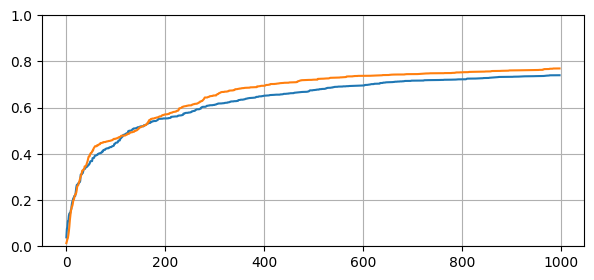

In [115]:
func = 6
sel1 = 0
sel2 = 2
repl = 0
fig = plt.figure(figsize=(7,3))
plt.plot(np.mean(AllData[sel1,repl,func,:,0,:],axis=0))
plt.plot(np.mean(AllData[sel2,repl,func,:,0,:],axis=0))
plt.ylim(0,1)
plt.grid(True)
plt.show()

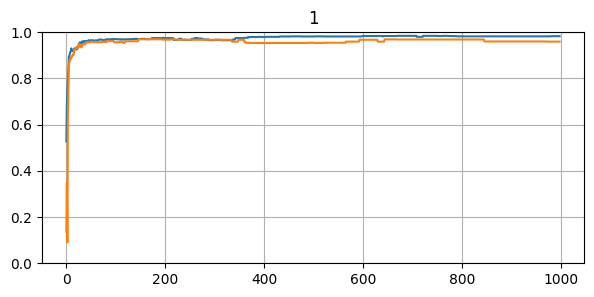

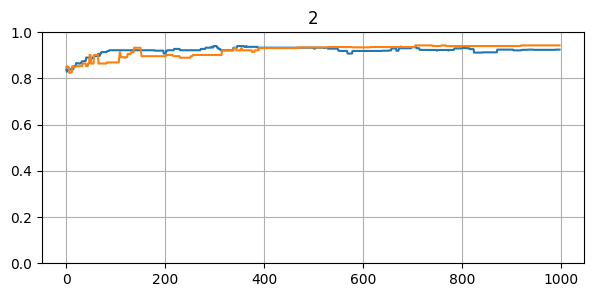

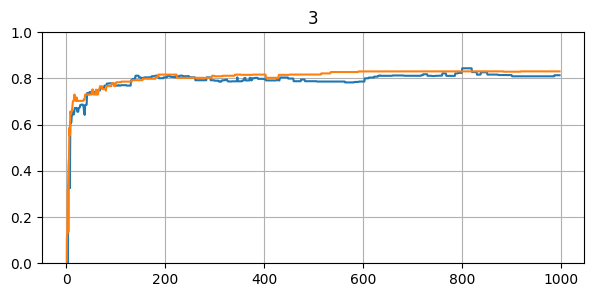

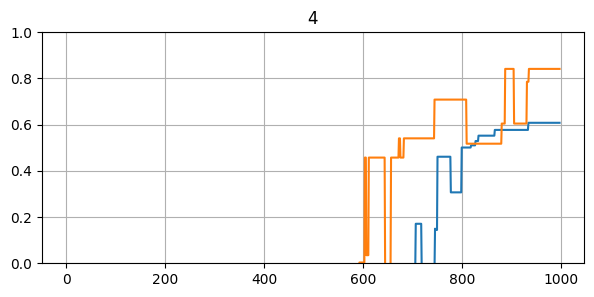

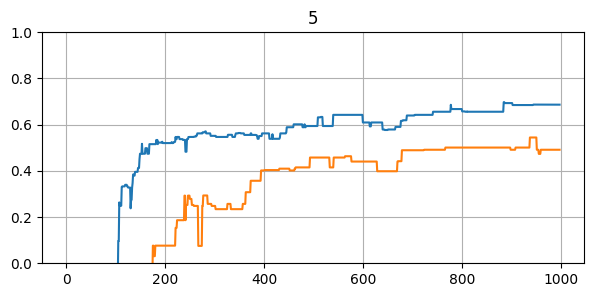

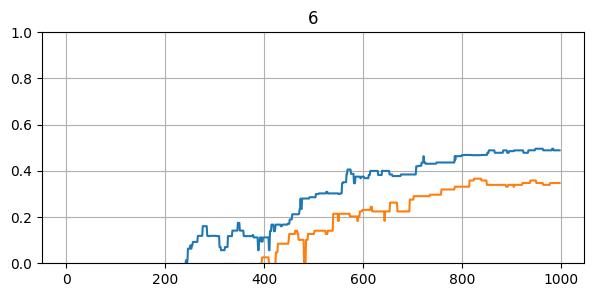

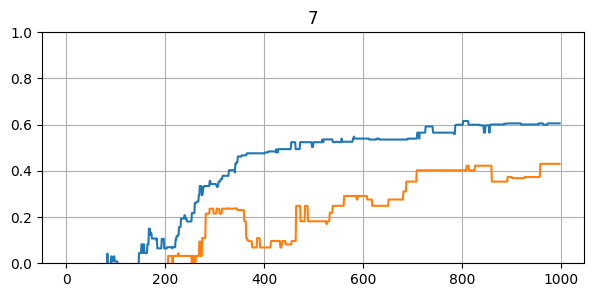

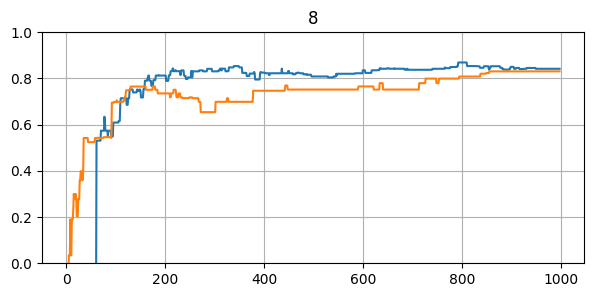

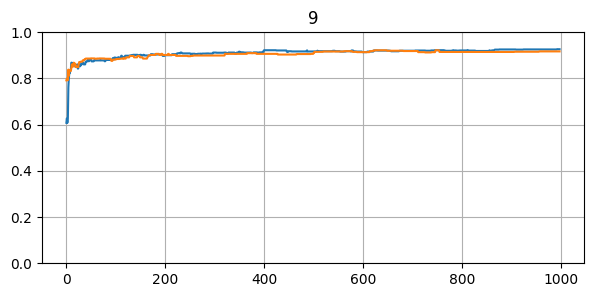

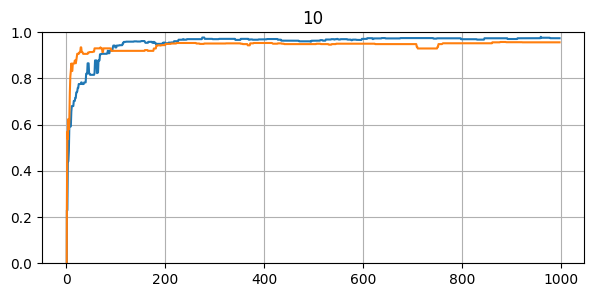

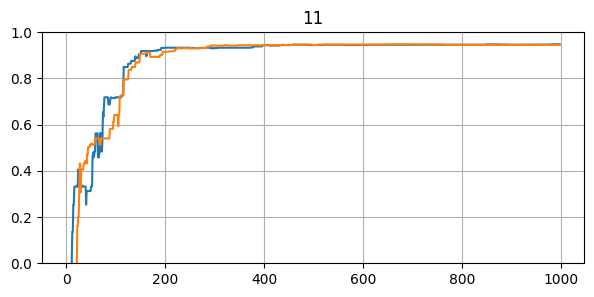

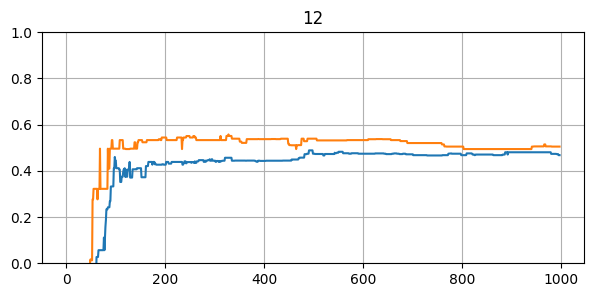

In [126]:
for func in range(12):
    sel1 = 2
    repl1 = 0
    sel2 = 3
    repl2 = 0
    fig = plt.figure(figsize=(7,3))
    plt.plot(np.median(AllData[sel1,repl1,func,:,1,:],axis=0))
    plt.plot(np.median(AllData[sel2,repl2,func,:,1,:],axis=0))
    plt.ylim(0,1)
    plt.grid(True)
    plt.title(f'{func+1}')
    plt.show()

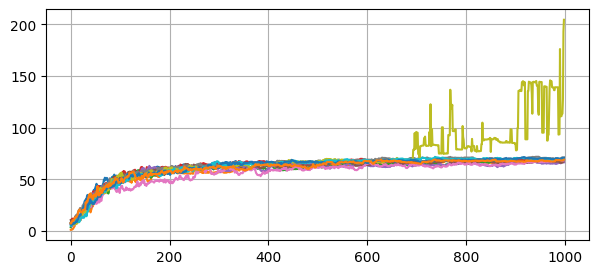

In [95]:
fig = plt.figure(figsize=(7,3))
for func in range(0,nfunc):
    plt.plot(np.mean(AllData[sel,repl,func,:,2,:],axis=0))
#plt.ylim(0,1)
plt.grid(True)
plt.show()

In [161]:
sel1 = 3
repl1 = 1

for sel2 in range(0,5):
    for repl2 in range(0,2):
        nplus = 0
        nminus = 0
        nequal = 0
        totalZ = 0
        for func in range(nfunc):
            data1 = AllData[sel1,repl1,func,:,0,998]
            data2 = AllData[sel2,repl2,func,:,0,998]
            test, Zscore = MannWhitneyU_myZ(data2,data1)
            #print(f'{np.median(data1):.3f}, {np.median(data2):.3f}')
            #print(func,test,f'{Zscore:.2f}')
            if(test == -1):
                nminus += 1
            if(test == 0):
                nequal += 1
            if(test == 1):
                nplus += 1
            totalZ += Zscore
        print(sel1,repl1,'vs',sel2,repl2,f'is {nminus}-/{nequal}=/{nplus}+/{totalZ:.2f}')

3 1 vs 0 0 is 11-/1=/0+/-59.24
3 1 vs 0 1 is 8-/4=/0+/-48.72
3 1 vs 1 0 is 9-/3=/0+/-52.87
3 1 vs 1 1 is 8-/4=/0+/-47.48
3 1 vs 2 0 is 11-/1=/0+/-56.31
3 1 vs 2 1 is 8-/3=/1+/-44.63
3 1 vs 3 0 is 4-/8=/0+/-22.57
3 1 vs 3 1 is 0-/12=/0+/0.00
3 1 vs 4 0 is 11-/1=/0+/-59.35
3 1 vs 4 1 is 11-/1=/0+/-47.85


In [54]:
PATH = "/home/mpiscil/cloud/GP18_25_Results/"

nruns = 25
nfunc = 10
nsel = 6
nrepl = 2
np1sel = 2
datalen = 100

AllData = np.zeros((nsel,nrepl,np1sel,nfunc,nruns,3,datalen))

for sel in range(0,nsel):
    for repl in range(0,nrepl):
        for p1sel in range(0,np1sel):
            filename = PATH+f"Results_S{sel}_C0_M0_R{repl}_P{p1sel}_T3_MD5_ML75.txt"
            print(filename)
            data = np.loadtxt(filename)
            print(data.shape)
            for run in range(nruns):
                AllData[sel,repl,p1sel,:,run,0,:] = data[run:nruns*nfunc:nruns,0:datalen*3:3]
                AllData[sel,repl,p1sel,:,run,1,:] = data[run:nruns*nfunc:nruns,1:datalen*3:3]
                AllData[sel,repl,p1sel,:,run,2,:] = data[run:nruns*nfunc:nruns,2:datalen*3:3]

/home/mpiscil/cloud/GP18_25_Results/Results_S0_C0_M0_R0_P0_T3_MD5_ML75.txt
(250, 300)
/home/mpiscil/cloud/GP18_25_Results/Results_S0_C0_M0_R0_P1_T3_MD5_ML75.txt
(250, 300)
/home/mpiscil/cloud/GP18_25_Results/Results_S0_C0_M0_R1_P0_T3_MD5_ML75.txt
(250, 300)
/home/mpiscil/cloud/GP18_25_Results/Results_S0_C0_M0_R1_P1_T3_MD5_ML75.txt
(250, 300)
/home/mpiscil/cloud/GP18_25_Results/Results_S1_C0_M0_R0_P0_T3_MD5_ML75.txt
(250, 300)
/home/mpiscil/cloud/GP18_25_Results/Results_S1_C0_M0_R0_P1_T3_MD5_ML75.txt
(250, 300)
/home/mpiscil/cloud/GP18_25_Results/Results_S1_C0_M0_R1_P0_T3_MD5_ML75.txt
(250, 300)
/home/mpiscil/cloud/GP18_25_Results/Results_S1_C0_M0_R1_P1_T3_MD5_ML75.txt
(250, 300)
/home/mpiscil/cloud/GP18_25_Results/Results_S2_C0_M0_R0_P0_T3_MD5_ML75.txt
(250, 300)
/home/mpiscil/cloud/GP18_25_Results/Results_S2_C0_M0_R0_P1_T3_MD5_ML75.txt
(250, 300)
/home/mpiscil/cloud/GP18_25_Results/Results_S2_C0_M0_R1_P0_T3_MD5_ML75.txt
(250, 300)
/home/mpiscil/cloud/GP18_25_Results/Results_S2_C0_M0_R

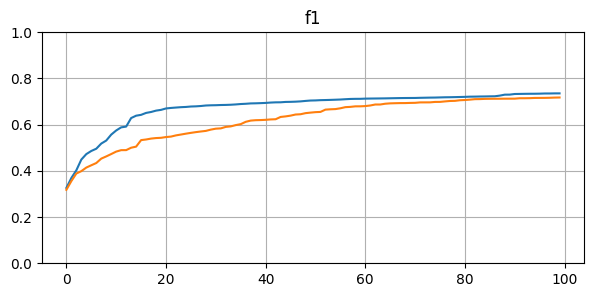

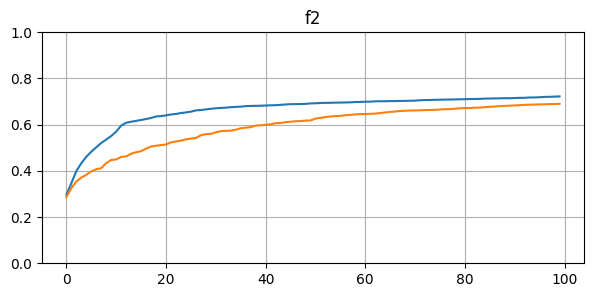

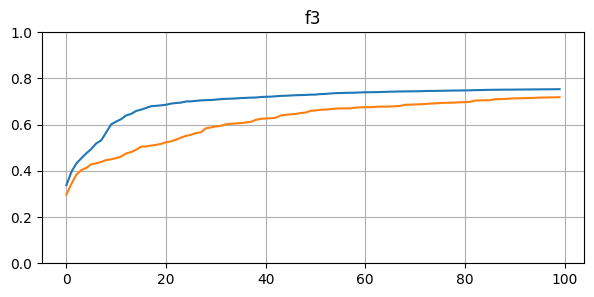

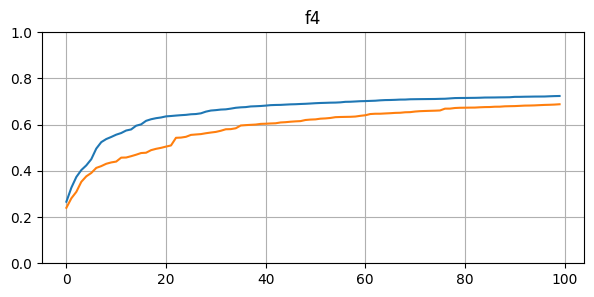

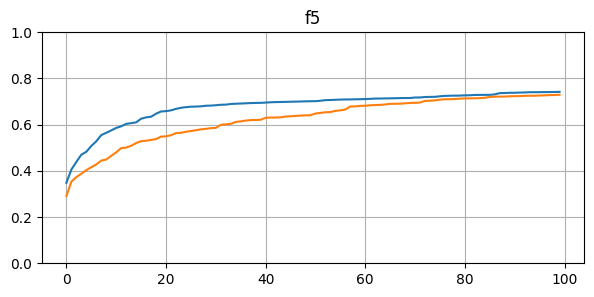

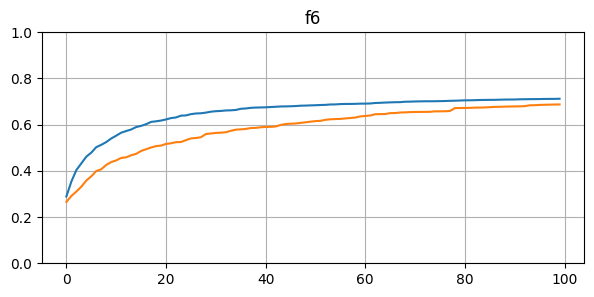

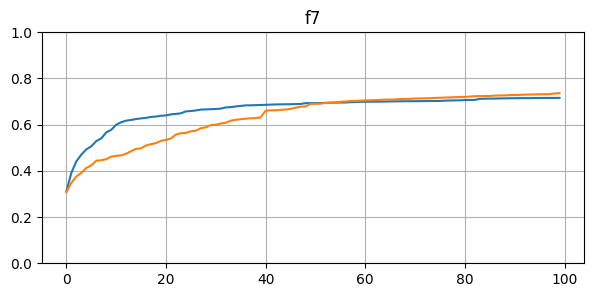

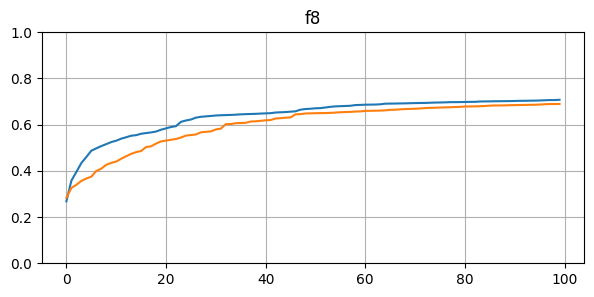

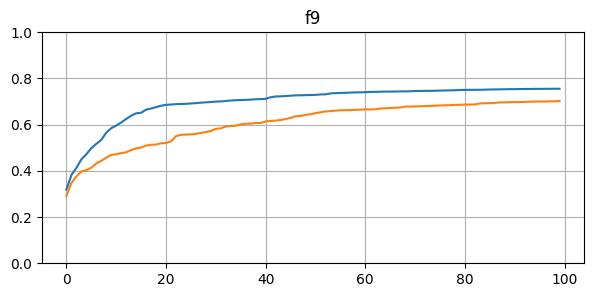

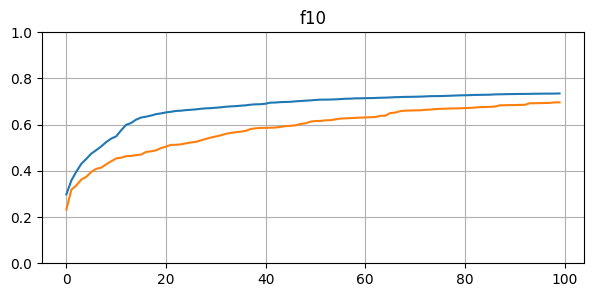

In [98]:
func = 0

for func in range(10):
    sel1 = 0
    p1sel1 = 0
    repl1 = 1
    
    sel2 = 0
    p1sel2 = 1
    repl2 = 1
    
    fig = plt.figure(figsize=(7,3))
    plt.plot(np.mean(AllData[sel1,repl1,p1sel1,func,:,0,:],axis=0))
    plt.plot(np.mean(AllData[sel2,repl2,p1sel2,func,:,0,:],axis=0))
    plt.ylim(0,1)
    plt.title(f'f{func+1}')
    plt.grid(True)
    plt.show()

In [99]:
sel1 = 3
repl1 = 1
p1sel1 = 0

for sel2 in range(0,6):
    for repl2 in range(0,2):
        for p1sel2 in range(0,2):
            nplus = 0
            nminus = 0
            nequal = 0
            totalZ = 0
            for func in range(nfunc):
                data1 = AllData[sel1,repl1,p1sel1,func,:,0,49]
                data2 = AllData[sel2,repl2,p1sel2,func,:,0,49]
                test, Zscore = MannWhitneyU_myZ(data2,data1)
                #print(f'{np.median(data1):.3f}, {np.median(data2):.3f}')
                #print(func,test,f'{Zscore:.2f}')
                if(test == -1):
                    nminus += 1
                if(test == 0):
                    nequal += 1
                if(test == 1):
                    nplus += 1
                totalZ += Zscore
            print(sel1,repl1,p1sel1,'vs',sel2,repl2,p1sel2,f'is {nminus}-/{nequal}=/{nplus}+/{totalZ:.2f}')

3 1 0 vs 0 0 0 is 0-/10=/0+/-19.77
3 1 0 vs 0 0 1 is 9-/1=/0+/-32.25
3 1 0 vs 0 1 0 is 0-/10=/0+/-13.00
3 1 0 vs 0 1 1 is 3-/7=/0+/-22.57
3 1 0 vs 1 0 0 is 0-/10=/0+/-15.21
3 1 0 vs 1 0 1 is 9-/1=/0+/-32.07
3 1 0 vs 1 1 0 is 0-/10=/0+/-12.17
3 1 0 vs 1 1 1 is 1-/9=/0+/-21.44
3 1 0 vs 2 0 0 is 0-/10=/0+/-19.27
3 1 0 vs 2 0 1 is 10-/0=/0+/-41.17
3 1 0 vs 2 1 0 is 0-/10=/0+/-11.45
3 1 0 vs 2 1 1 is 9-/1=/0+/-33.45
3 1 0 vs 3 0 0 is 0-/10=/0+/-7.18
3 1 0 vs 3 0 1 is 1-/9=/0+/-23.19
3 1 0 vs 3 1 0 is 0-/10=/0+/0.00
3 1 0 vs 3 1 1 is 0-/10=/0+/-9.57
3 1 0 vs 4 0 0 is 0-/10=/0+/-15.46
3 1 0 vs 4 0 1 is 9-/1=/0+/-31.01
3 1 0 vs 4 1 0 is 0-/10=/0+/-4.93
3 1 0 vs 4 1 1 is 1-/9=/0+/-18.06
3 1 0 vs 5 0 0 is 0-/10=/0+/0.89
3 1 0 vs 5 0 1 is 0-/10=/0+/-12.63
3 1 0 vs 5 1 0 is 0-/10=/0+/11.41
3 1 0 vs 5 1 1 is 0-/10=/0+/3.07


In [22]:
PATH = "/home/mpiscil/cloud/GP18_25_Results/"

nruns = 25
nfunc = 10
nsel = 5
np1sel = 2
nrepl = 5
datalen = 100

AllData = np.zeros((nsel,nrepl,np1sel,nfunc,nruns,3,datalen))

for sel in range(0,5):
    for p1sel in range(0,2):
        for repl in range(0,5):
            filename = PATH+f"Results_f_S{sel}_C0_M0_R{repl}_P{p1sel}_T3_TR3_MD5_ML150.txt"
            print(filename)
            data = np.loadtxt(filename)
            print(data.shape)
            for run in range(nruns):
                AllData[sel,repl,p1sel,:,run,0,:] = data[run:nruns*nfunc:nruns,0:datalen*3:3]
                AllData[sel,repl,p1sel,:,run,1,:] = data[run:nruns*nfunc:nruns,1:datalen*3:3]
                AllData[sel,repl,p1sel,:,run,2,:] = data[run:nruns*nfunc:nruns,2:datalen*3:3]

/home/mpiscil/cloud/GP18_25_Results/Results_f_S0_C0_M0_R0_P0_T3_TR3_MD5_ML150.txt
(250, 300)
/home/mpiscil/cloud/GP18_25_Results/Results_f_S0_C0_M0_R1_P0_T3_TR3_MD5_ML150.txt
(250, 300)
/home/mpiscil/cloud/GP18_25_Results/Results_f_S0_C0_M0_R2_P0_T3_TR3_MD5_ML150.txt
(250, 300)
/home/mpiscil/cloud/GP18_25_Results/Results_f_S0_C0_M0_R3_P0_T3_TR3_MD5_ML150.txt
(250, 300)
/home/mpiscil/cloud/GP18_25_Results/Results_f_S0_C0_M0_R4_P0_T3_TR3_MD5_ML150.txt
(250, 300)
/home/mpiscil/cloud/GP18_25_Results/Results_f_S0_C0_M0_R0_P1_T3_TR3_MD5_ML150.txt
(250, 300)
/home/mpiscil/cloud/GP18_25_Results/Results_f_S0_C0_M0_R1_P1_T3_TR3_MD5_ML150.txt
(250, 300)
/home/mpiscil/cloud/GP18_25_Results/Results_f_S0_C0_M0_R2_P1_T3_TR3_MD5_ML150.txt
(250, 300)
/home/mpiscil/cloud/GP18_25_Results/Results_f_S0_C0_M0_R3_P1_T3_TR3_MD5_ML150.txt
(250, 300)
/home/mpiscil/cloud/GP18_25_Results/Results_f_S0_C0_M0_R4_P1_T3_TR3_MD5_ML150.txt
(250, 300)
/home/mpiscil/cloud/GP18_25_Results/Results_f_S1_C0_M0_R0_P0_T3_TR3_MD

In [23]:
ComapreStep = 99
SampleNum = 1

In [24]:
sel1 = 3
p1sel1 = 0
repl1 = 3


for sel2 in range(0,5):
    for p1sel2 in range(0,2):
        for repl2 in range(0,5):        
            nplus = 0
            nminus = 0
            nequal = 0
            totalZ = 0
            for func in range(nfunc):
                data1 = AllData[sel1,repl1,p1sel1,func,:,SampleNum,ComapreStep]
                data2 = AllData[sel2,repl2,p1sel2,func,:,SampleNum,ComapreStep]
                test, Zscore = MannWhitneyU_myZ(data2,data1)
                #print(f'{np.median(data1):.3f}, {np.median(data2):.3f}')
                #print(func,test,f'{Zscore:.2f}')
                if(test == -1):
                    nminus += 1
                if(test == 0):
                    nequal += 1
                if(test == 1):
                    nplus += 1
                totalZ += Zscore
            print(sel1,p1sel1,repl1,'vs',sel2,p1sel2,repl2,f'is {nminus}-/{nequal}=/{nplus}+/{totalZ:.2f}')

3 0 3 vs 0 0 0 is 0-/10=/0+/-13.06
3 0 3 vs 0 0 1 is 0-/10=/0+/3.43
3 0 3 vs 0 0 2 is 0-/10=/0+/-2.87
3 0 3 vs 0 0 3 is 0-/10=/0+/-15.87
3 0 3 vs 0 0 4 is 0-/10=/0+/-14.63
3 0 3 vs 0 1 0 is 0-/10=/0+/-12.92
3 0 3 vs 0 1 1 is 0-/10=/0+/-2.48
3 0 3 vs 0 1 2 is 0-/10=/0+/0.60
3 0 3 vs 0 1 3 is 0-/10=/0+/-14.86
3 0 3 vs 0 1 4 is 0-/10=/0+/-17.40
3 0 3 vs 1 0 0 is 0-/10=/0+/-12.32
3 0 3 vs 1 0 1 is 0-/10=/0+/6.34
3 0 3 vs 1 0 2 is 0-/10=/0+/0.74
3 0 3 vs 1 0 3 is 0-/10=/0+/-16.12
3 0 3 vs 1 0 4 is 0-/10=/0+/-17.23
3 0 3 vs 1 1 0 is 0-/10=/0+/-9.04
3 0 3 vs 1 1 1 is 0-/10=/0+/-4.75
3 0 3 vs 1 1 2 is 0-/10=/0+/-1.94
3 0 3 vs 1 1 3 is 0-/10=/0+/-14.14
3 0 3 vs 1 1 4 is 0-/10=/0+/-15.13
3 0 3 vs 2 0 0 is 0-/10=/0+/-9.39
3 0 3 vs 2 0 1 is 0-/10=/0+/5.69
3 0 3 vs 2 0 2 is 0-/10=/0+/-0.41
3 0 3 vs 2 0 3 is 0-/10=/0+/-15.66
3 0 3 vs 2 0 4 is 0-/10=/0+/-13.78
3 0 3 vs 2 1 0 is 0-/10=/0+/-11.91
3 0 3 vs 2 1 1 is 0-/10=/0+/-6.69
3 0 3 vs 2 1 2 is 0-/10=/0+/3.53
3 0 3 vs 2 1 3 is 0-/10=/0+/-15.50
3 0 3

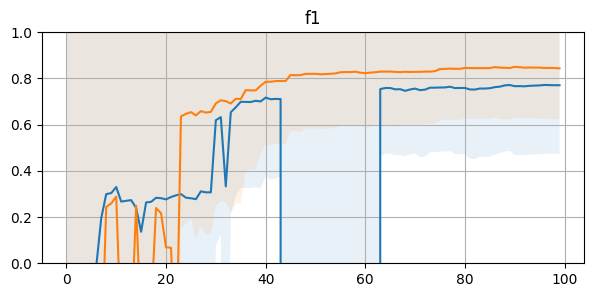

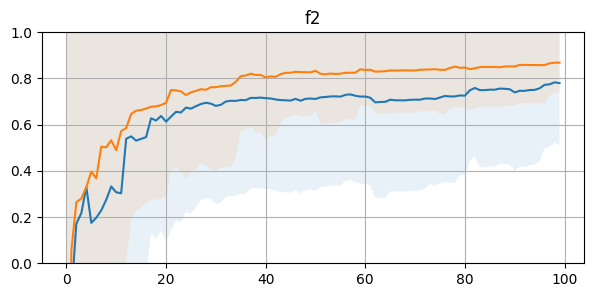

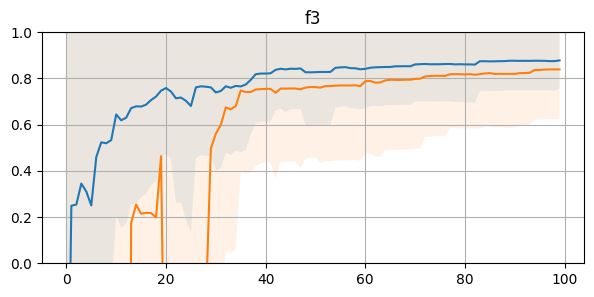

/home/mpiscil/anaconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:197: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


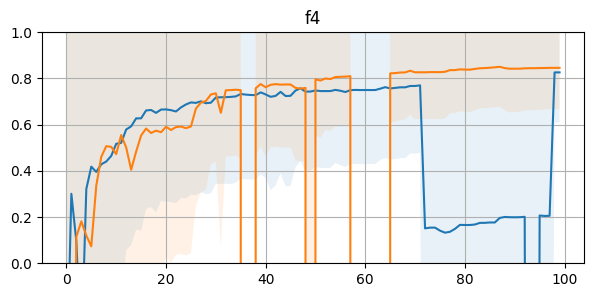

/home/mpiscil/anaconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:194: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


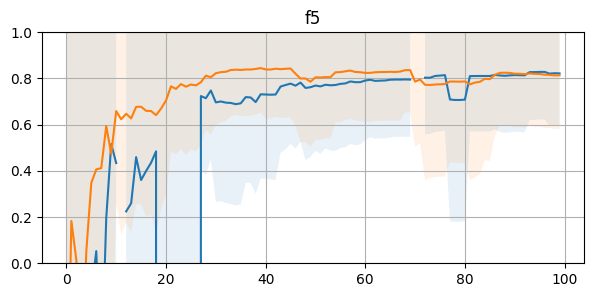

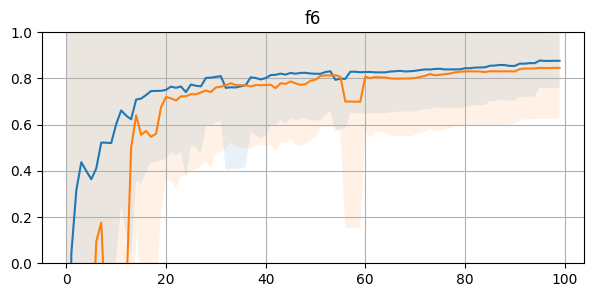

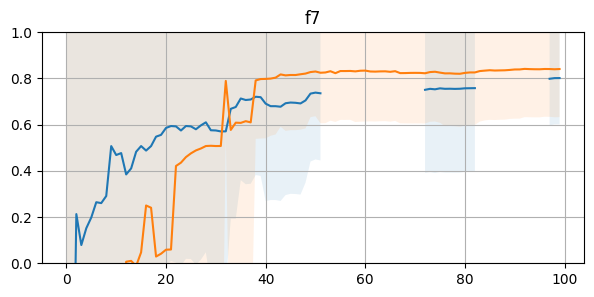

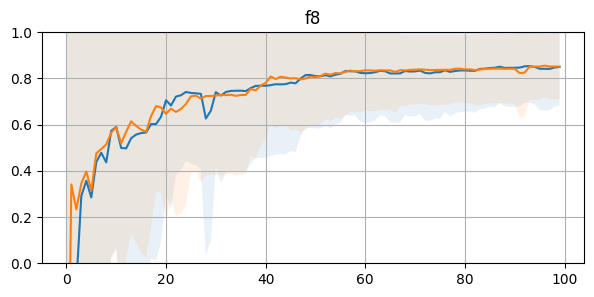

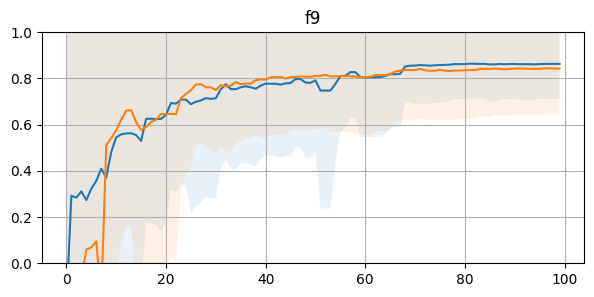

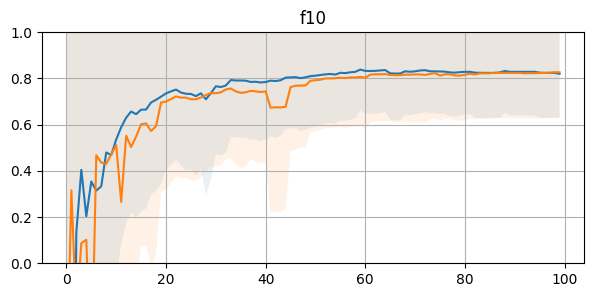

In [25]:
for func in range(10):
    sel1 = 3
    p1sel1 = 0
    repl1 = 1
    
    sel2 = 4
    p1sel2 = 0
    repl2 = 1

    idx = np.arange(0,100)
    
    fig = plt.figure(figsize=(7,3))
    plt.plot(idx,np.mean(AllData[sel1,repl1,p1sel1,func,:,SampleNum,:],axis=0))
    plt.fill_between(idx,np.mean(AllData[sel1,repl1,p1sel1,func,:,SampleNum,:],axis=0)-np.std(AllData[sel1,repl1,p1sel1,func,:,SampleNum,:],axis=0),np.mean(AllData[sel1,repl1,p1sel1,func,:,SampleNum,:],axis=0)+np.std(AllData[sel1,repl1,p1sel1,func,:,SampleNum,:],axis=0),alpha=0.1)
    plt.plot(np.mean(AllData[sel2,repl2,p1sel2,func,:,SampleNum,:],axis=0))
    plt.fill_between(idx,np.mean(AllData[sel2,repl2,p1sel2,func,:,SampleNum,:],axis=0)-np.std(AllData[sel2,repl2,p1sel2,func,:,SampleNum,:],axis=0),np.mean(AllData[sel2,repl2,p1sel2,func,:,SampleNum,:],axis=0)+np.std(AllData[sel2,repl2,p1sel2,func,:,SampleNum,:],axis=0),alpha=0.1)
    plt.ylim(0,1)
    plt.title(f'f{func+1}')
    plt.grid(True)
    plt.show()

In [26]:
5*2*5

50

In [27]:
NTests = 50
NRuns = 25
FRTotal = np.zeros((NTests))  
FRPerFunc = np.zeros((nfunc,NTests))
for func in range(0,nfunc):    
    ResFunction = np.zeros((NTests,NRuns,nfunc))    
    FRFunc = np.zeros(NTests) 
    testindex = 0
    #repl2indexes = [6,0,1,2,3,4,5]
    for sel2 in range(0,5):
        for p1sel2 in range(0,2):
            for repl2 in range(0,5): 
                #repl2 = repl2indexes[repl2iter]
                #for func in range(nfunc):
                ResFunction[testindex,:,func] = -AllData[sel2,repl2,p1sel2,func,:,SampleNum,ComapreStep] 
                testindex+=1
    FRFunc = FriedmanSTest(ResFunction, func, NTests, NRuns)+1
    FRPerFunc[func] = FRFunc
    FRTotal += FRFunc

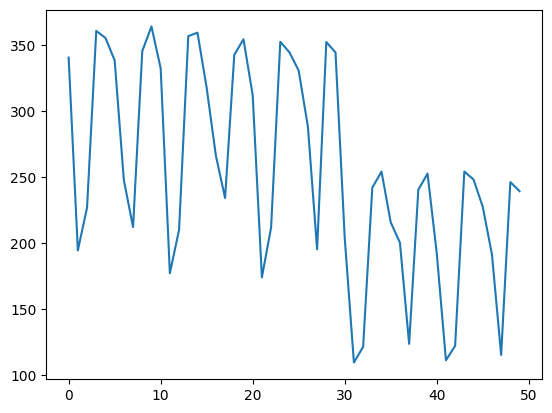

In [28]:
FRTotal
plt.plot(FRTotal)
plt.show()

In [29]:
np.argmin(FRTotal)+1

np.int64(32)

In [30]:
testindex = 0
selnames = ["1.1","1.2","1.3","1.4","1.5"]
p1selnames = ["2.1","2.2"]
replnames = ["3.1","3.2","3.3","3.4","3.5"]
#repl2indexes = [6,0,1,2,3,4,5]
SumSel = np.zeros(5)
SumP1sel = np.zeros(2)
SumRepl = np.zeros(5)
str1 = "#\tSelection\tFirst parent\tReplacement\tM-W test\tZ-score\tFriedman rank\n"
for sel2 in range(0,5):
    for p1sel2 in range(0,2):
        for repl2 in range(0,5): 
            #repl2 = repl2indexes[repl2iter]
            nplus = 0
            nminus = 0
            nequal = 0
            totalZ = 0
            for func in range(nfunc):
                data1 = AllData[sel1,repl1,p1sel1,func,:,SampleNum,ComapreStep]
                data2 = AllData[sel2,repl2,p1sel2,func,:,SampleNum,ComapreStep]
                test, Zscore = MannWhitneyU_myZ(data2,data1)
                #print(f'{np.median(data1):.3f}, {np.median(data2):.3f}')
                #print(func,test,f'{Zscore:.2f}')
                if(test == -1):
                    nminus += 1
                if(test == 0):
                    nequal += 1
                if(test == 1):
                    nplus += 1
                totalZ += Zscore
            #print(testindex,sel1,p1sel1,repl1,'vs',sel2,p1sel2,repl2,f'is {nminus}-/{nequal}=/{nplus}+/{totalZ:.2f}+/{FRTotal[testindex]:.2f}')
            str1 += f'{testindex+1}\t'#,sel1,p1sel1,repl1,'vs',sel2,p1sel2,repl2,f'is {nminus}-/{nequal}=/{nplus}+/{totalZ:.2f}+/{FRTotal[testindex]:.2f}')
            str1 += f'{selnames[sel2]}\t'
            str1 += f'{p1selnames[p1sel2]}\t'
            str1 += f'{replnames[repl2]}\t'
            str1 += f'{nminus}-/{nequal}=/{nplus}+\t'
            str1 += f'{totalZ:.2f}\t'
            str1 += f'{FRTotal[testindex]:.2f}'
            str1 += "\n"
            SumSel[sel2] += FRTotal[testindex]
            SumP1sel[p1sel2] += FRTotal[testindex]
            SumRepl[repl2] += FRTotal[testindex]
            testindex += 1            
print(str1)

#	Selection	First parent	Replacement	M-W test	Z-score	Friedman rank
1	1.1	2.1	3.1	9-/1=/0+	-31.63	340.30
2	1.1	2.1	3.2	0-/10=/0+	-15.81	194.46
3	1.1	2.1	3.3	4-/6=/0+	-21.15	226.84
4	1.1	2.1	3.4	10-/0=/0+	-33.86	360.46
5	1.1	2.1	3.5	10-/0=/0+	-33.66	355.20
6	1.1	2.2	3.1	9-/1=/0+	-31.36	338.20
7	1.1	2.2	3.2	3-/7=/0+	-23.88	247.58
8	1.1	2.2	3.3	3-/7=/0+	-17.81	212.14
9	1.1	2.2	3.4	10-/0=/0+	-32.71	345.16
10	1.1	2.2	3.5	10-/0=/0+	-33.72	363.82
11	1.2	2.1	3.1	8-/2=/0+	-30.89	332.22
12	1.2	2.1	3.2	0-/10=/0+	-11.43	177.18
13	1.2	2.1	3.3	0-/10=/0+	-17.34	210.08
14	1.2	2.1	3.4	10-/0=/0+	-33.63	356.50
15	1.2	2.1	3.5	10-/0=/0+	-34.61	359.16
16	1.2	2.2	3.1	7-/3=/0+	-28.19	317.38
17	1.2	2.2	3.2	5-/5=/0+	-25.26	266.16
18	1.2	2.2	3.3	2-/8=/0+	-21.89	234.08
19	1.2	2.2	3.4	7-/3=/0+	-31.74	342.36
20	1.2	2.2	3.5	10-/0=/0+	-32.85	354.16
21	1.3	2.1	3.1	8-/2=/0+	-27.94	311.96
22	1.3	2.1	3.2	0-/10=/0+	-10.56	174.08
23	1.3	2.1	3.3	1-/9=/0+	-17.38	211.76
24	1.3	2.1	3.4	10-/0=/0+	-32.34	352.22
25	1.3	2.1	3.5	10

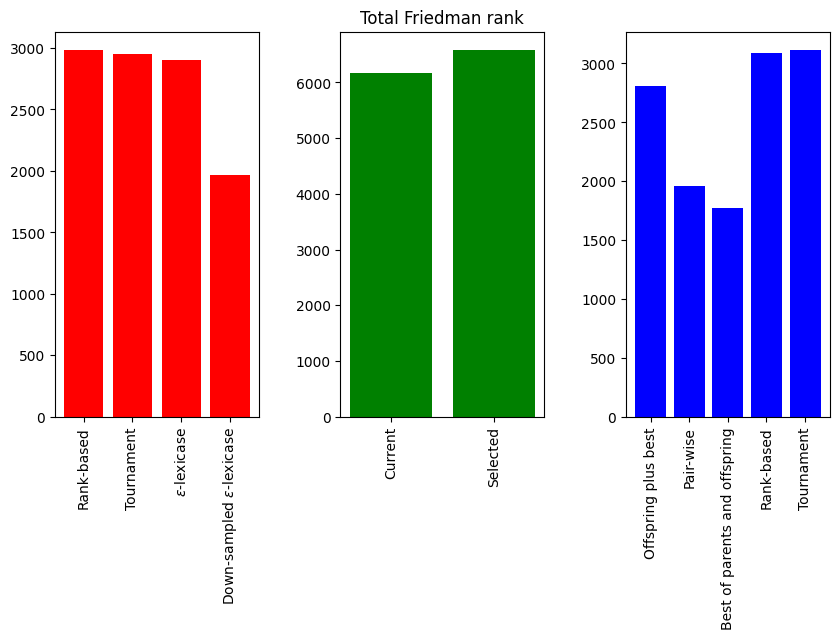

In [40]:
selnames2 = ['Rank-based','Tournament',r'$\varepsilon$-lexicase',r'Down-sampled $\varepsilon$-lexicase',r'Contrastive Down-sampled $\varepsilon$-lexicase']
p1selnames2 = ['Current','Selected']
replnames2 = ['Offspring plus best','Pair-wise','Best of parents and offspring','Rank-based','Tournament']
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1,3)
gs.update(wspace=0.40, hspace=0.75) # set the spacing between axes. 
ax = []
ax.append(plt.subplot(gs[0]))
ax.append(plt.subplot(gs[1]))
ax.append(plt.subplot(gs[2]))
ax[0].bar(np.arange(4),SumSel[:4], color ='r')
ax[0].set_xticks([0,1,2,3])
ax[0].set_xticklabels(selnames2[:4],rotation=90)

ax[1].bar(np.arange(2),SumP1sel, color ='g')
ax[1].set_xticks([0,1])
ax[1].set_xticklabels(p1selnames2,rotation=90)
ax[1].set_title("Total Friedman rank")

ax[2].bar(np.arange(5),SumRepl, color ='b')
ax[2].set_xticks([0,1,2,3,4])
ax[2].set_xticklabels(replnames2,rotation=90)
#fig.savefig('barplot_gpsel.png',bbox_inches="tight")
#fig.savefig('barplot_gpsel.svg',bbox_inches="tight")
plt.show()
fig.savefig("barplot_eng.png",bbox_inches="tight")


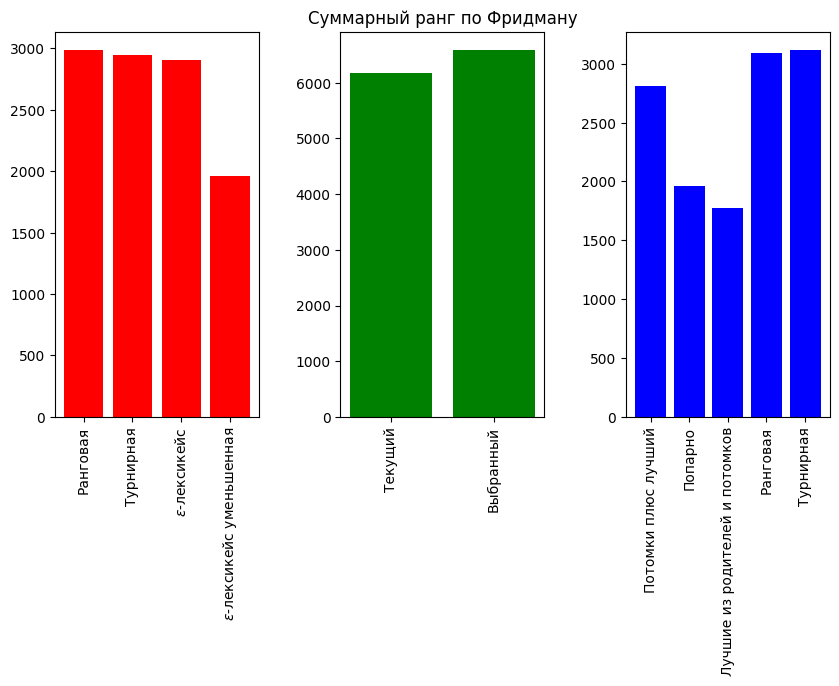

In [39]:
selnames2 = ['Ранговая','Турнирная',r'$\varepsilon$-лексикейс',r'$\varepsilon$-лексикейс уменьшенная',r'Contrastive Down-sampled $\varepsilon$-lexicase']
p1selnames2 = ['Текущий','Выбранный']
replnames2 = ['Потомки плюс лучший','Попарно','Лучшие из родителей и потомков','Ранговая','Турнирная']
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1,3)
gs.update(wspace=0.40, hspace=0.75) # set the spacing between axes. 
ax = []
ax.append(plt.subplot(gs[0]))
ax.append(plt.subplot(gs[1]))
ax.append(plt.subplot(gs[2]))
ax[0].bar(np.arange(4),SumSel[:4], color ='r')
ax[0].set_xticks([0,1,2,3])
ax[0].set_xticklabels(selnames2[:4],rotation=90)

ax[1].bar(np.arange(2),SumP1sel, color ='g')
ax[1].set_xticks([0,1])
ax[1].set_xticklabels(p1selnames2,rotation=90)
ax[1].set_title("Суммарный ранг по Фридману")

ax[2].bar(np.arange(5),SumRepl, color ='b')
ax[2].set_xticks([0,1,2,3,4])
ax[2].set_xticklabels(replnames2,rotation=90)
#fig.savefig('barplot_gpsel.png',bbox_inches="tight")
#fig.savefig('barplot_gpsel.svg',bbox_inches="tight")
plt.show()
fig.savefig("barplot_rus.png",bbox_inches="tight")


In [298]:
PATH = "/home/mpiscil/cloud/GP18_25_Results/"

nruns = 25
nfunc = 96
nsel = 23
np1sel = 2
nrepl = 4
datalen = 50

AllData = np.zeros((nsel,nrepl,np1sel,nfunc,nruns,3,datalen))
allfilenames = []

for sel in range(0,23):
    for p1sel in range(0,2):
        for repl in range(0,4,1):
            filename = PATH+f"Results_25FRONT96_S{sel+1}_C0_M0_R{repl}_P{p1sel}_T3_TR3_MD7_ML75.txt"
            #if(filename == "/home/mpiscil/cloud/GP18_25_Results/Results_25FRONT96_S6_C0_M0_R3_P1_T3_TR3_MD7_ML75.txt"):
            #    filename = "/home/mpiscil/cloud/GP18_25_Results/Results_25FRONT96_S5_C0_M0_R3_P1_T3_TR3_MD7_ML75.txt"
            print(filename)
            allfilenames.append(filename)
            data = np.loadtxt(filename)
            print(data.shape)
            for run in range(nruns):
                AllData[sel,repl,p1sel,:,run,0,:] = data[run:nruns*nfunc:nruns,0:datalen*3:3]
                AllData[sel,repl,p1sel,:,run,1,:] = data[run:nruns*nfunc:nruns,1:datalen*3:3]
                AllData[sel,repl,p1sel,:,run,2,:] = data[run:nruns*nfunc:nruns,2:datalen*3:3]

/home/mpiscil/cloud/GP18_25_Results/Results_25FRONT96_S1_C0_M0_R0_P0_T3_TR3_MD7_ML75.txt
(2400, 150)
/home/mpiscil/cloud/GP18_25_Results/Results_25FRONT96_S1_C0_M0_R1_P0_T3_TR3_MD7_ML75.txt
(2400, 150)
/home/mpiscil/cloud/GP18_25_Results/Results_25FRONT96_S1_C0_M0_R2_P0_T3_TR3_MD7_ML75.txt
(2400, 150)
/home/mpiscil/cloud/GP18_25_Results/Results_25FRONT96_S1_C0_M0_R3_P0_T3_TR3_MD7_ML75.txt
(2400, 150)
/home/mpiscil/cloud/GP18_25_Results/Results_25FRONT96_S1_C0_M0_R0_P1_T3_TR3_MD7_ML75.txt
(2400, 150)
/home/mpiscil/cloud/GP18_25_Results/Results_25FRONT96_S1_C0_M0_R1_P1_T3_TR3_MD7_ML75.txt
(2400, 150)
/home/mpiscil/cloud/GP18_25_Results/Results_25FRONT96_S1_C0_M0_R2_P1_T3_TR3_MD7_ML75.txt
(2400, 150)
/home/mpiscil/cloud/GP18_25_Results/Results_25FRONT96_S1_C0_M0_R3_P1_T3_TR3_MD7_ML75.txt
(2400, 150)
/home/mpiscil/cloud/GP18_25_Results/Results_25FRONT96_S2_C0_M0_R0_P0_T3_TR3_MD7_ML75.txt
(2400, 150)
/home/mpiscil/cloud/GP18_25_Results/Results_25FRONT96_S2_C0_M0_R1_P0_T3_TR3_MD7_ML75.txt
(2

In [299]:
ComapreStep = 49
SampleNum = 1

sel1 = 3
p1sel1 = 1
repl1 = 2


for sel2 in range(0,23):
    for p1sel2 in range(0,2):
        for repl2 in range(0,4,1):        
            nplus = 0
            nminus = 0
            nequal = 0
            totalZ = 0
            for func in range(nfunc):
                data1 = AllData[sel1,repl1,p1sel1,func,:,SampleNum,ComapreStep]
                data2 = AllData[sel2,repl2,p1sel2,func,:,SampleNum,ComapreStep]
                test, Zscore = MannWhitneyU_myZ(data2,data1)
                #print(f'{np.median(data1):.3f}, {np.median(data2):.3f}')
                #print(func,test,f'{Zscore:.2f}')
                if(test == -1):
                    nminus += 1
                if(test == 0):
                    nequal += 1
                if(test == 1):
                    nplus += 1
                totalZ += Zscore
            print(sel1,p1sel1,repl1,'vs',sel2,p1sel2,repl2,f'is {nminus}-/{nequal}=/{nplus}+/{totalZ:.2f}')

3 1 2 vs 0 0 0 is 69-/27=/0+/-350.76
3 1 2 vs 0 0 1 is 1-/95=/0+/-93.09
3 1 2 vs 0 0 2 is 0-/96=/0+/-53.28
3 1 2 vs 0 0 3 is 22-/74=/0+/-180.02
3 1 2 vs 0 1 0 is 55-/41=/0+/-300.49
3 1 2 vs 0 1 1 is 3-/93=/0+/-58.05
3 1 2 vs 0 1 2 is 0-/96=/0+/-18.26
3 1 2 vs 0 1 3 is 20-/76=/0+/-143.72
3 1 2 vs 1 0 0 is 72-/24=/0+/-364.89
3 1 2 vs 1 0 1 is 15-/81=/0+/-153.33
3 1 2 vs 1 0 2 is 1-/95=/0+/-61.81
3 1 2 vs 1 0 3 is 19-/77=/0+/-176.79
3 1 2 vs 1 1 0 is 54-/42=/0+/-311.11
3 1 2 vs 1 1 1 is 10-/86=/0+/-114.09
3 1 2 vs 1 1 2 is 0-/96=/0+/-31.42
3 1 2 vs 1 1 3 is 19-/77=/0+/-141.58
3 1 2 vs 2 0 0 is 62-/34=/0+/-341.51
3 1 2 vs 2 0 1 is 6-/90=/0+/-103.15
3 1 2 vs 2 0 2 is 0-/96=/0+/-33.44
3 1 2 vs 2 0 3 is 15-/81=/0+/-160.01
3 1 2 vs 2 1 0 is 51-/45=/0+/-291.22
3 1 2 vs 2 1 1 is 7-/89=/0+/-80.50
3 1 2 vs 2 1 2 is 0-/95=/1+/-4.77
3 1 2 vs 2 1 3 is 19-/77=/0+/-136.84
3 1 2 vs 3 0 0 is 63-/33=/0+/-319.96
3 1 2 vs 3 0 1 is 0-/96=/0+/-60.23
3 1 2 vs 3 0 2 is 0-/96=/0+/-40.24
3 1 2 vs 3 0 3 is 22-/74=

In [300]:
NTests = 92*2
NRuns = 25
FRTotal = np.zeros((NTests))  
FRPerFunc = np.zeros((nfunc,NTests))
for func in range(0,nfunc):    
    ResFunction = np.zeros((NTests,NRuns,nfunc))    
    FRFunc = np.zeros(NTests) 
    testindex = 0
    #repl2indexes = [6,0,1,2,3,4,5]
    for sel2 in range(0,23):
        for p1sel2 in range(0,2):
            for repl2 in range(0,4,1): 
                #repl2 = repl2indexes[repl2iter]
                #for func in range(nfunc):
                ResFunction[testindex,:,func] = -AllData[sel2,repl2,p1sel2,func,:,SampleNum,ComapreStep] 
                testindex+=1
    FRFunc = FriedmanSTest(ResFunction, func, NTests, NRuns)+1
    FRPerFunc[func] = FRFunc
    FRTotal += FRFunc

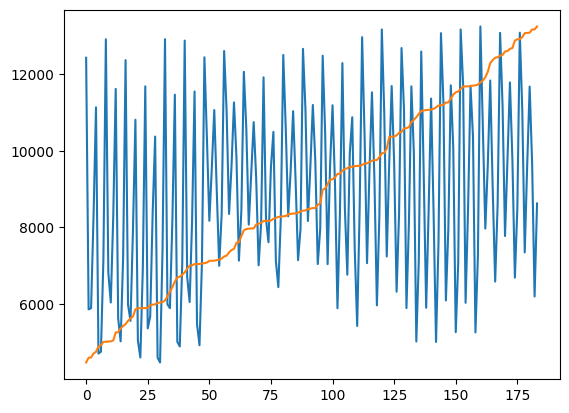

In [301]:
FRTotal
plt.plot(FRTotal)
plt.plot(np.sort(FRTotal))
plt.show()

In [302]:
testindex = 0
selnames = [f"1.{s+1}" for s in range(23)]
p1selnames = [f"2.{s+1}" for s in range(2)]
replnames = [f"3.{s+1}" for s in range(4)]
#repl2indexes = [6,0,1,2,3,4,5]
SumSel = np.zeros(23)
SumSelDS = np.zeros(23)
SumP1sel = np.zeros(2)
SumRepl = np.zeros(4)
str1 = "#\tSelection\tDown-sampling\tReplacement\tM-W test\tZ-score\tFriedman rank\n"
for sel2 in range(0,23):
    for p1sel2 in range(0,2):
        for repl2 in range(0,4,1): 
            #repl2 = repl2indexes[repl2iter]
            nplus = 0
            nminus = 0
            nequal = 0
            totalZ = 0
            for func in range(nfunc):
                data1 = AllData[sel1,repl1,p1sel1,func,:,SampleNum,ComapreStep]
                data2 = AllData[sel2,repl2,p1sel2,func,:,SampleNum,ComapreStep]
                test, Zscore = MannWhitneyU_myZ(data2,data1)
                #print(f'{np.median(data1):.3f}, {np.median(data2):.3f}')
                #print(func,test,f'{Zscore:.2f}')
                if(test == -1):
                    nminus += 1
                if(test == 0):
                    nequal += 1
                if(test == 1):
                    nplus += 1
                totalZ += Zscore
            #print(testindex,sel1,p1sel1,repl1,'vs',sel2,p1sel2,repl2,f'is {nminus}-/{nequal}=/{nplus}+/{totalZ:.2f}+/{FRTotal[testindex]:.2f}')
            str1 += f'{testindex+1}\t'#,sel1,p1sel1,repl1,'vs',sel2,p1sel2,repl2,f'is {nminus}-/{nequal}=/{nplus}+/{totalZ:.2f}+/{FRTotal[testindex]:.2f}')
            str1 += f'{selnames[sel2]}\t'
            str1 += f'{p1selnames[p1sel2]}\t'
            str1 += f'{replnames[repl2]}\t'
            str1 += f'{nminus}-/{nequal}=/{nplus}+\t'
            str1 += f'{totalZ:.2f}\t'
            str1 += f'{FRTotal[testindex]:.2f}'
            str1 += "\n"
            SumSel[sel2] += FRTotal[testindex]
            SumP1sel[p1sel2] += FRTotal[testindex]
            SumRepl[repl2] += FRTotal[testindex]
            if(p1sel2 == 1):
                SumSelDS[sel2] += FRTotal[testindex]
            testindex += 1            
print(str1)

#	Selection	Down-sampling	Replacement	M-W test	Z-score	Friedman rank
1	1.1	2.1	3.1	69-/27=/0+	-350.76	12428.68
2	1.1	2.1	3.2	1-/95=/0+	-93.09	5859.74
3	1.1	2.1	3.3	0-/96=/0+	-53.28	5889.84
4	1.1	2.1	3.4	22-/74=/0+	-180.02	8296.62
5	1.1	2.2	3.1	55-/41=/0+	-300.49	11134.82
6	1.1	2.2	3.2	3-/93=/0+	-58.05	4706.62
7	1.1	2.2	3.3	0-/96=/0+	-18.26	4752.08
8	1.1	2.2	3.4	20-/76=/0+	-143.72	7157.00
9	1.2	2.1	3.1	72-/24=/0+	-364.89	12910.54
10	1.2	2.1	3.2	15-/81=/0+	-153.33	6824.46
11	1.2	2.1	3.3	1-/95=/0+	-61.81	6038.86
12	1.2	2.1	3.4	19-/77=/0+	-176.79	8278.84
13	1.2	2.2	3.1	54-/42=/0+	-311.11	11615.74
14	1.2	2.2	3.2	10-/86=/0+	-114.09	5624.48
15	1.2	2.2	3.3	0-/96=/0+	-31.42	5024.28
16	1.2	2.2	3.4	19-/77=/0+	-141.58	7185.00
17	1.3	2.1	3.1	62-/34=/0+	-341.51	12366.32
18	1.3	2.1	3.2	6-/90=/0+	-103.15	5982.44
19	1.3	2.1	3.3	0-/96=/0+	-33.44	5559.16
20	1.3	2.1	3.4	15-/81=/0+	-160.01	7923.66
21	1.3	2.2	3.1	51-/45=/0+	-291.22	10810.16
22	1.3	2.2	3.2	7-/89=/0+	-80.50	5047.28
23	1.3	2.2	3.3	0-/95=/1+	-4

In [308]:
np.argsort(FRTotal)

array([ 30,  29,  22,   5,   6,  38,  46, 142,  37, 134,  14,  21, 158,
       150,  25, 110,  45,  18,  13,  26,   1, 102,   2,  34, 130, 138,
       118,  17,  33, 154,  10,  42, 146, 182, 126,  78, 166, 174,  41,
       106,   9,  23,  54,  70,  98,  94,  39, 151, 114,  47, 135,  77,
        62,  86,   7,  15, 122, 159, 178,  31, 109, 143,  74, 170,  19,
        87,  95, 162, 147,  66,  71, 131,  90,  43,  50,  35,  73,  79,
       119,  11,  82,   3,  55,  58, 127, 103,  27, 141, 139,  63, 155,
       111, 105, 175, 167, 183,  53, 165, 101,  85, 117,  69, 137,  67,
        83, 115,  51,  75,  91,  59, 163,  99, 179, 123, 181, 125,  93,
       171, 173,  61, 107, 133, 149,  49, 157,  28, 113,  97,  76,  65,
       161,  81,  68,  20, 108, 121,  84,  57,  52, 177, 129,  89,   4,
       169, 100,  92, 145,  60, 140,  36, 116,  44,  12, 180, 132,  24,
       124, 156, 148, 153, 172, 164,  72,  64, 104,  16,   0,  48,  96,
        80, 136,  56,  88, 128,  40,   8,  32, 112, 144, 168, 17

In [304]:
FRsortindex = np.argsort(FRTotal)
for k in range(10):
    print(FRsortindex[k],allfilenames[FRsortindex[k]])

30 /home/mpiscil/cloud/GP18_25_Results/Results_25FRONT96_S4_C0_M0_R2_P1_T3_TR3_MD7_ML75.txt
29 /home/mpiscil/cloud/GP18_25_Results/Results_25FRONT96_S4_C0_M0_R1_P1_T3_TR3_MD7_ML75.txt
22 /home/mpiscil/cloud/GP18_25_Results/Results_25FRONT96_S3_C0_M0_R2_P1_T3_TR3_MD7_ML75.txt
5 /home/mpiscil/cloud/GP18_25_Results/Results_25FRONT96_S1_C0_M0_R1_P1_T3_TR3_MD7_ML75.txt
6 /home/mpiscil/cloud/GP18_25_Results/Results_25FRONT96_S1_C0_M0_R2_P1_T3_TR3_MD7_ML75.txt
38 /home/mpiscil/cloud/GP18_25_Results/Results_25FRONT96_S5_C0_M0_R2_P1_T3_TR3_MD7_ML75.txt
46 /home/mpiscil/cloud/GP18_25_Results/Results_25FRONT96_S6_C0_M0_R2_P1_T3_TR3_MD7_ML75.txt
142 /home/mpiscil/cloud/GP18_25_Results/Results_25FRONT96_S18_C0_M0_R2_P1_T3_TR3_MD7_ML75.txt
37 /home/mpiscil/cloud/GP18_25_Results/Results_25FRONT96_S5_C0_M0_R1_P1_T3_TR3_MD7_ML75.txt
134 /home/mpiscil/cloud/GP18_25_Results/Results_25FRONT96_S17_C0_M0_R2_P1_T3_TR3_MD7_ML75.txt


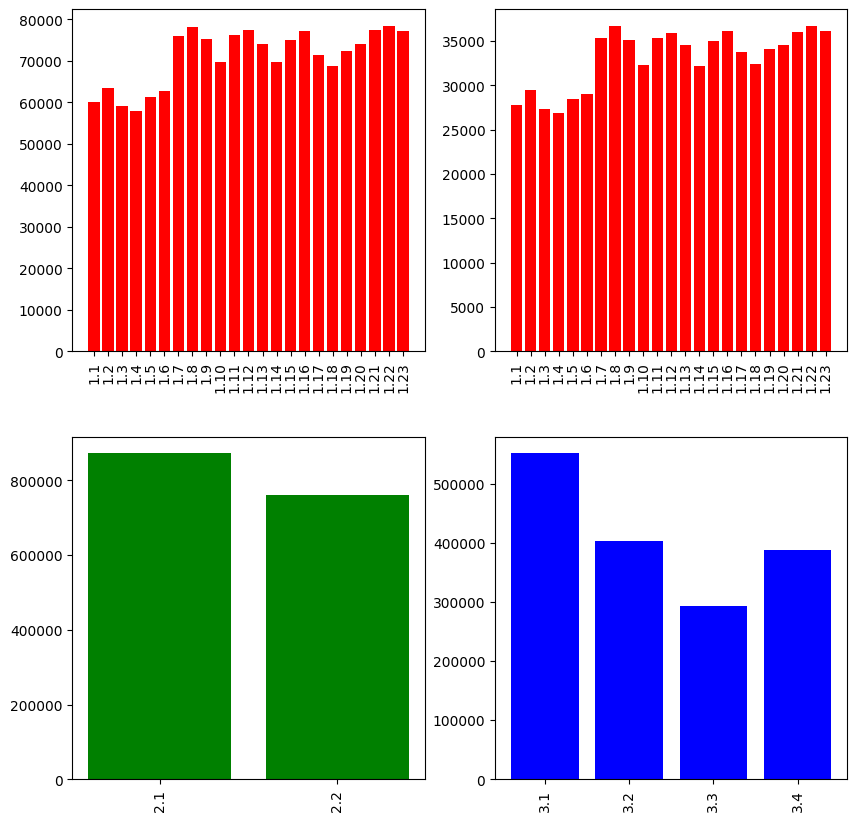

In [516]:
#selnames2 = ['Rank-based','Tournament',r'$\varepsilon$-lexicase',r'Down-sampled $\varepsilon$-lexicase',r'Contrastive Down-sampled $\varepsilon$-lexicase']
#p1selnames2 = ['Current','Selected']
#replnames2 = ['Offspring plus best','Pair-wise','Best of parents and offspring','Rank-based','Tournament']
fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(2,2)
gs.update(wspace=0.20, hspace=0.25) # set the spacing between axes. 
ax = []
ax.append(plt.subplot(gs[0]))
ax.append(plt.subplot(gs[1]))
ax.append(plt.subplot(gs[2]))
ax.append(plt.subplot(gs[3]))
ax[0].bar(np.arange(23),SumSel, color ='r')
ax[0].set_xticks(np.arange(23))
ax[0].set_xticklabels(selnames,rotation=90)

ax[1].bar(np.arange(23),SumSelDS, color ='r')
ax[1].set_xticks(np.arange(23))
ax[1].set_xticklabels(selnames,rotation=90)

ax[2].bar(np.arange(2),SumP1sel, color ='g')
ax[2].set_xticks([0,1])
ax[2].set_xticklabels(p1selnames,rotation=90)
#ax[2].set_title("Total Friedman rank")

ax[3].bar(np.arange(4),SumRepl, color ='b')
ax[3].set_xticks([0,1,2,3])
ax[3].set_xticklabels(replnames,rotation=90)
#fig.savefig('barplot_gpsel.png',bbox_inches="tight")
#fig.savefig('barplot_gpsel.svg',bbox_inches="tight")
plt.show()


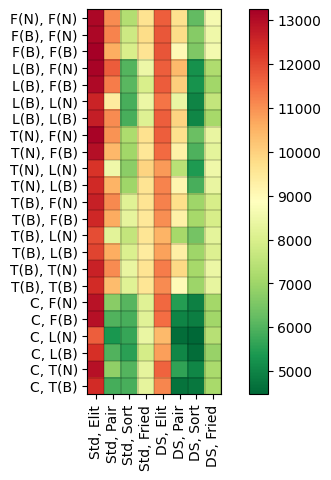

In [600]:
Sel_labels = [
    "C, T(B)",
    "C, T(N)",
    "C, L(B)",
    "C, L(N)",
    "C, F(B)",
    "C, F(N)",
    "T(B), T(B)",
    "T(B), T(N)",
    "T(B), L(B)",
    "T(B), L(N)",
    "T(B), F(B)",
    "T(B), F(N)",
    "T(N), L(B)",
    "T(N), L(N)",
    "T(N), F(B)",
    "T(N), F(N)",
    "L(B), L(B)",
    "L(B), L(N)",
    "L(B), F(B)",
    "L(B), F(N)",
    "F(B), F(B)",
    "F(B), F(N)",
    "F(N), F(N)"
]
Rep_DS_labels = [
    "Std, Elit",
    "Std, Pair",
    "Std, Sort",
    "Std, Fried",
    "DS, Elit",
    "DS, Pair",
    "DS, Sort",
    "DS, Fried"
]
testindex = 0
FRImage = np.zeros((23,8))
for sel2 in range(0,23):
    for p1sel2 in range(0,2):
        for repl2 in range(0,4,1): 
            FRImage[sel2][p1sel2*4+repl2] = FRTotal[testindex]
            testindex += 1    

fig, ax = plt.subplots(figsize=(7, 5))
#gs = gridspec.GridSpec(1,1)
#gs.update(wspace=0.40, hspace=0.75) # set the spacing between axes. 
#ax = []
#ax.append(plt.subplot(gs[0]))
 
plt.imshow(FRImage,cmap = 'RdYlGn_r')
ax.set_yticks(np.arange(23))
ax.set_yticklabels(Sel_labels)
ax.set_xticks(np.arange(8))
ax.set_xticklabels(Rep_DS_labels,rotation=90)
plt.colorbar()
plt.hlines(y=np.arange(0, 23)+0.5, xmin=np.full(23, 0)-0.5, xmax=np.full(23, 8)-0.5, color="black",lw=0.2)
plt.vlines(x=np.arange(0, 8)+0.5, ymin=np.full(8, 0)-0.5, ymax=np.full(8, 23)-0.5, color="black",lw=0.2)
plt.xlim(-0.5,7.5)
plt.ylim(-0.5,22.5)
#plt.title("Friedman ranks of all experiments")
plt.show()
fig.savefig("/home/mpiscil/Documents/EUROGP_2025/Figures_tmp/Fig1.png",bbox_inches="tight")
fig.savefig("/home/mpiscil/Documents/EUROGP_2025/Figures_tmp/Fig1.pdf",bbox_inches="tight")
fig.savefig("/home/mpiscil/Documents/EUROGP_2025/Figures_tmp/Fig1.svg",bbox_inches="tight")

In [588]:
np.full(23, 0)-0.5

array([-0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5,
       -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5,
       -0.5])

In [589]:
np.full(23, 8)-0.5

array([7.5, 7.5, 7.5, 7.5, 7.5, 7.5, 7.5, 7.5, 7.5, 7.5, 7.5, 7.5, 7.5,
       7.5, 7.5, 7.5, 7.5, 7.5, 7.5, 7.5, 7.5, 7.5, 7.5])

In [587]:
np.arange(0, 23)+0.5

array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
       11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5,
       22.5])

In [311]:
FRImage

array([[12428.68,  5859.74,  5889.84,  8296.62, 11134.82,  4706.62,
         4752.08,  7157.  ],
       [12910.54,  6824.46,  6038.86,  8278.84, 11615.74,  5624.48,
         5024.28,  7185.  ],
       [12366.32,  5982.44,  5559.16,  7923.66, 10810.16,  5047.28,
         4602.26,  6922.76],
       [11682.52,  5363.18,  5673.78,  8382.28, 10371.5 ,  4597.16,
         4472.8 ,  7408.42],
       [12914.62,  5990.66,  5891.08,  8180.32, 11465.2 ,  5013.6 ,
         4890.56,  7044.86],
       [12876.58,  6713.14,  6050.32,  8170.3 , 11548.32,  5474.22,
         4921.06,  7080.92],
       [12441.12, 10362.64,  8172.26,  9546.24, 11063.5 ,  8981.64,
         6997.6 ,  8343.74],
       [12605.72, 11053.9 ,  8349.96,  9596.58, 11262.46,  9836.58,
         7131.26,  8441.96],
       [12061.92, 10583.26,  8070.76,  9397.76, 10748.14,  9302.7 ,
         7010.4 ,  8095.14],
       [11917.76,  8222.18,  7611.96,  9576.08, 10494.16,  7127.06,
         6439.56,  8246.62],
       [12502.  , 10615.6 ,  8

In [365]:
ComapreStep = 49
SampleNum = 1

sel1 = 3
p1sel1 = 1
repl1 = 2

MWTable = np.zeros((23,23,5))

for sel1 in range(0,23):
    for sel2 in range(sel1,23):
        for p1sel2 in range(1,2):
            for repl2 in range(2,3,1):        
                nplus = 0
                nminus = 0
                nequal = 0
                totalZ = 0
                for func in range(nfunc):
                    data1 = AllData[sel1,repl1,p1sel1,func,:,SampleNum,ComapreStep]
                    data2 = AllData[sel2,repl2,p1sel2,func,:,SampleNum,ComapreStep]
                    test, Zscore = MannWhitneyU_myZ(data2,data1)
                    #print(f'{np.median(data1):.3f}, {np.median(data2):.3f}')
                    #print(func,test,f'{Zscore:.2f}')
                    if(test == -1):
                        nminus += 1
                    if(test == 0):
                        nequal += 1
                    if(test == 1):
                        nplus += 1
                    totalZ += Zscore
                print(sel1,p1sel1,repl1,'vs',sel2,p1sel2,repl2,f'is {nminus}-/{nequal}=/{nplus}+/{totalZ:.2f}')
                MWTable[sel1,sel2,0] = nplus
                MWTable[sel1,sel2,1] = nequal
                MWTable[sel1,sel2,2] = nminus
                MWTable[sel1,sel2,3] = nplus-nminus
                MWTable[sel1,sel2,4] = totalZ

0 1 2 vs 0 1 2 is 0-/96=/0+/0.00
0 1 2 vs 1 1 2 is 1-/95=/0+/-15.81
0 1 2 vs 2 1 2 is 0-/95=/1+/12.25
0 1 2 vs 3 1 2 is 0-/96=/0+/18.26
0 1 2 vs 4 1 2 is 0-/95=/1+/-4.57
0 1 2 vs 5 1 2 is 0-/96=/0+/-5.80
0 1 2 vs 6 1 2 is 18-/78=/0+/-143.50
0 1 2 vs 7 1 2 is 24-/72=/0+/-156.19
0 1 2 vs 8 1 2 is 24-/72=/0+/-152.06
0 1 2 vs 9 1 2 is 11-/85=/0+/-122.86
0 1 2 vs 10 1 2 is 27-/69=/0+/-159.52
0 1 2 vs 11 1 2 is 28-/68=/0+/-153.13
0 1 2 vs 12 1 2 is 3-/93=/0+/-92.09
0 1 2 vs 13 1 2 is 3-/93=/0+/-69.53
0 1 2 vs 14 1 2 is 10-/86=/0+/-99.91
0 1 2 vs 15 1 2 is 8-/88=/0+/-113.55
0 1 2 vs 16 1 2 is 1-/95=/0+/-39.52
0 1 2 vs 17 1 2 is 1-/95=/0+/-30.70
0 1 2 vs 18 1 2 is 2-/94=/0+/-55.12
0 1 2 vs 19 1 2 is 0-/96=/0+/-52.56
0 1 2 vs 20 1 2 is 16-/80=/0+/-128.45
0 1 2 vs 21 1 2 is 15-/81=/0+/-126.03
0 1 2 vs 22 1 2 is 10-/86=/0+/-105.92
1 1 2 vs 1 1 2 is 0-/96=/0+/0.00
1 1 2 vs 2 1 2 is 0-/96=/0+/25.83
1 1 2 vs 3 1 2 is 0-/96=/0+/31.42
1 1 2 vs 4 1 2 is 0-/96=/0+/8.29
1 1 2 vs 5 1 2 is 0-/95=/1+/7.02
1

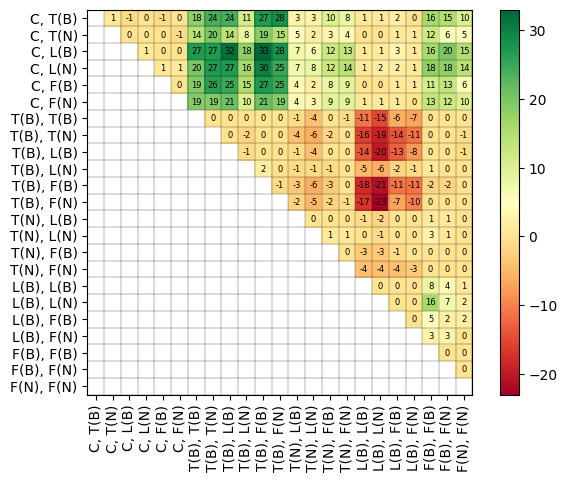

In [584]:
fig, ax = plt.subplots(figsize=(7, 5))
#plt.imshow(MWTable[:,:,3],cmap = 'RdYlGn_r')

#value = -1
data = MWTable[:,:,3]
#data[5, :] = -1  # Values to set -1

#masked_array = np.ma.masked_where(data == 0, data)

masked_array = data
for i in range(23):
    for j in range(i,23):
        data[j][i] = -5000
masked_array = np.ma.masked_where(data == -5000, data)
for i in range(23):
    for j in range(23):
        if(data[i][j] == -5000):
            pass
        else:
            plt.text(j, i, f'{int(-masked_array[i][j])}', ha='center', va='center', fontsize=6)#, color=color)
            

cmap = matplotlib.cm.RdYlGn  # Can be any colormap that you want after the cm
cmap.set_bad(color='white')


#plt.pcolormesh(np.zeros((23,23)).T, edgecolors='k', linewidth=1)
plt.imshow(-masked_array, cmap=cmap)
#plt.imshow(MWTable[:,:,3],cmap = 'RdYlGn_r')



ax.set_yticks(np.arange(23))
ax.set_yticklabels(Sel_labels)
ax.set_xticks(np.arange(23))
ax.set_xticklabels(Sel_labels,rotation=90)
#ax.grid(which='minor', color='black', linestyle='-', linewidth=2)
#ax.tick_params(which='minor', bottom=False, left=False)
#ax.grid(color='black', linewidth=1)
#ax.set_frame_on(False)
plt.hlines(y=np.arange(0, 23)+0.5, xmin=np.full(23, 0)-0.5, xmax=np.full(23, 23)-0.5, color="black",lw=0.2)
plt.vlines(x=np.arange(0, 23)+0.5, ymin=np.full(23, 0)-0.5, ymax=np.full(23, 23)-0.5, color="black",lw=0.2)

plt.colorbar()
plt.show()
fig.savefig("/home/mpiscil/Documents/EUROGP_2025/Figures_tmp/Fig2.png",bbox_inches="tight")
fig.savefig("/home/mpiscil/Documents/EUROGP_2025/Figures_tmp/Fig2.pdf",bbox_inches="tight")
fig.savefig("/home/mpiscil/Documents/EUROGP_2025/Figures_tmp/Fig2.svg",bbox_inches="tight")

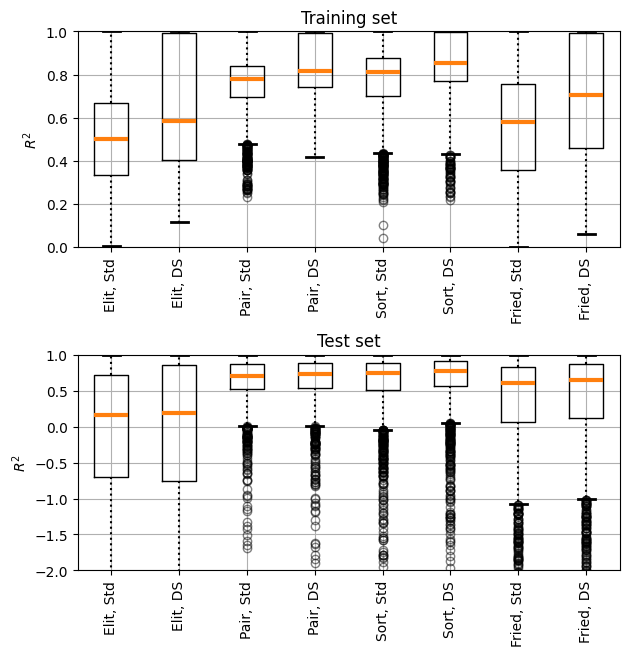

In [601]:
fig = plt.figure(figsize=(7, 7))

Rep_DS_labels = [
    "Elit, Std",
    "Elit, DS",
    "Pair, Std",
    "Pair, DS",
    "Sort, Std",
    "Sort, DS",
    "Fried, Std",
    "Fried, DS"
]

gs = gridspec.GridSpec(2,1)
gs.update(wspace=0.40, hspace=0.5) # set the spacing between axes. 
ax = []
ax.append(plt.subplot(gs[0]))
ax.append(plt.subplot(gs[1]))
bp = ax[0].boxplot(AllData[3:4,:,:,:,:,0,ComapreStep].transpose((1, 2, 0, 3, 4)).reshape(8,-1).T)
ax[0].set_ylim(0,1)
ax[0].set_xticks(np.arange(1,9))
ax[0].set_xticklabels(Rep_DS_labels,rotation=90)
ax[0].set_ylabel(r"$R^2$")
ax[0].grid(True)
ax[0].set_title("Training set")
for whisker in bp['whiskers']:
    whisker.set(#color ='#8B008B',
                linewidth = 1.5,
                linestyle =":")
# changing color and linewidth of
for cap in bp['caps']:
    cap.set(#color ='#8B008B',
            linewidth = 2)
for median in bp['medians']:
    median.set(#color ='red',
               linewidth = 3)
for flier in bp['fliers']:
    flier.set(marker ='o',
              #color ='#e7298a',
              alpha = 0.5)

bp1 = ax[1].boxplot(AllData[3:4,:,:,:,:,1,ComapreStep].transpose((1, 2, 0, 3, 4)).reshape(8,-1).T)
ax[1].set_ylim(-2,1)
ax[1].set_xticks(np.arange(1,9))
ax[1].set_xticklabels(Rep_DS_labels,rotation=90)
ax[1].set_ylabel(r"$R^2$")
ax[1].grid(True)
ax[1].set_title("Test set")

for whisker in bp1['whiskers']:
    whisker.set(#color ='#8B008B',
                linewidth = 1.5,
                linestyle =":")
# changing color and linewidth of
for cap in bp1['caps']:
    cap.set(#color ='#8B008B',
            linewidth = 2)
for median in bp1['medians']:
    median.set(#color ='red',
               linewidth = 3)
for flier in bp1['fliers']:
    flier.set(marker ='o',
              #color ='#e7298a',
              alpha = 0.5)

plt.show()

fig.savefig("/home/mpiscil/Documents/EUROGP_2025/Figures_tmp/Fig3.png",bbox_inches="tight")
fig.savefig("/home/mpiscil/Documents/EUROGP_2025/Figures_tmp/Fig3.pdf",bbox_inches="tight")
fig.savefig("/home/mpiscil/Documents/EUROGP_2025/Figures_tmp/Fig3.svg",bbox_inches="tight")

In [484]:
AllData[:,:,:,func,:,0,ComapreStep].reshape(23,-1).T.shape

(200, 23)

In [522]:
AllData[:,:,:,func,:,0,ComapreStep].shape

(23, 4, 2, 25)

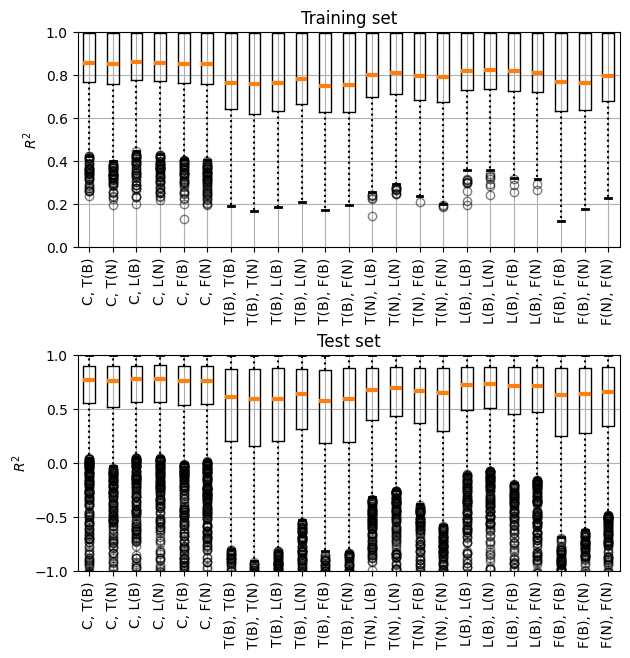

In [602]:
fig = plt.figure(figsize=(7, 7))
gs = gridspec.GridSpec(2,1)
gs.update(wspace=0.40, hspace=0.5) # set the spacing between axes. 
ax = []
ax.append(plt.subplot(gs[0]))
ax.append(plt.subplot(gs[1]))
bp = ax[0].boxplot(AllData[:,2,1,:,:,0,ComapreStep].reshape(23,-1).T)
ax[0].set_ylim(0,1)
ax[0].set_xticks(np.arange(1,24))
ax[0].set_xticklabels(Sel_labels,rotation=90)
ax[0].set_ylabel(r"$R^2$")
ax[0].grid(True)
ax[0].set_title("Training set")
for whisker in bp['whiskers']:
    whisker.set(#color ='#8B008B',
                linewidth = 1.5,
                linestyle =":")
# changing color and linewidth of
for cap in bp['caps']:
    cap.set(#color ='#8B008B',
            linewidth = 2)
for median in bp['medians']:
    median.set(#color ='red',
               linewidth = 3)
for flier in bp['fliers']:
    flier.set(marker ='o',
              #color ='#e7298a',
              alpha = 0.5)

bp1 = ax[1].boxplot(AllData[:,2,1,:,:,1,ComapreStep].reshape(23,-1).T)
ax[1].set_ylim(-1,1)
ax[1].set_xticks(np.arange(1,24))
ax[1].set_xticklabels(Sel_labels,rotation=90)
ax[1].set_ylabel(r"$R^2$")
ax[1].grid(True)
ax[1].set_title("Test set")

for whisker in bp1['whiskers']:
    whisker.set(#color ='#8B008B',
                linewidth = 1.5,
                linestyle =":")
# changing color and linewidth of
for cap in bp1['caps']:
    cap.set(#color ='#8B008B',
            linewidth = 2)
for median in bp1['medians']:
    median.set(#color ='red',
               linewidth = 3)
for flier in bp1['fliers']:
    flier.set(marker ='o',
              #color ='#e7298a',
              alpha = 0.5)

plt.show()

fig.savefig("/home/mpiscil/Documents/EUROGP_2025/Figures_tmp/Fig4.png",bbox_inches="tight")
fig.savefig("/home/mpiscil/Documents/EUROGP_2025/Figures_tmp/Fig4.pdf",bbox_inches="tight")
fig.savefig("/home/mpiscil/Documents/EUROGP_2025/Figures_tmp/Fig4.svg",bbox_inches="tight")

In [510]:
AllData[:,:,:,func,:,0,ComapreStep].transpose((1, 2, 0, 3)).reshape(8,-1).T.shape

(575, 8)

In [526]:
AllData[:,:,:,:,:,0,ComapreStep].shape

(23, 4, 2, 96, 25)

In [517]:
FRPerFunc.shape

(96, 184)

In [518]:
FRTable = np.zeros((23,2,4,96))
testindex = 0
for sel2 in range(0,23):
    for p1sel2 in range(0,2):
        for repl2 in range(0,4,1): 
            for func in range(0,nfunc):    
                FRTable[sel2,p1sel2,repl2,func] = FRPerFunc[func,testindex]
            testindex+=1    

In [534]:
FRTable.shape

(23, 2, 4, 96)

In [542]:
FRTable[:,:,:,:].reshape(23,-1).T.shape

(768, 23)

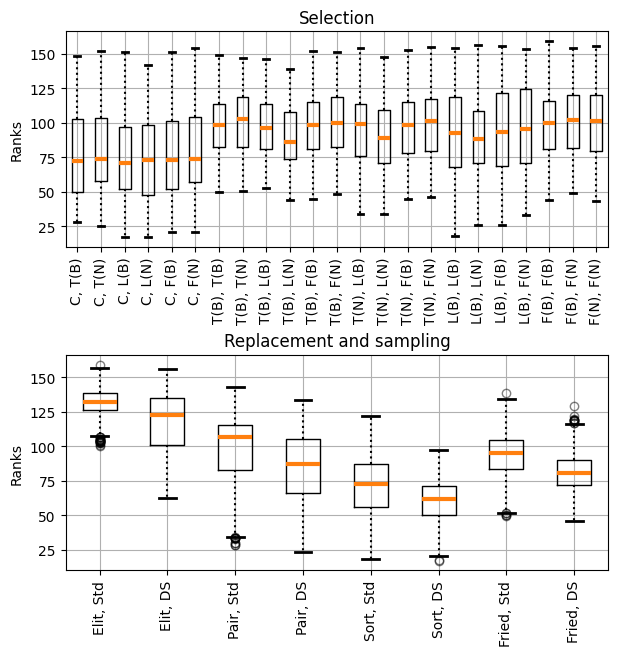

In [603]:
fig = plt.figure(figsize=(7, 7))
gs = gridspec.GridSpec(2,1)
gs.update(wspace=0.40, hspace=0.5) # set the spacing between axes. 
ax = []
ax.append(plt.subplot(gs[0]))
ax.append(plt.subplot(gs[1]))
bp = ax[0].boxplot(FRTable[:,:,:,:].reshape(23,-1).T)
#ax[0].set_ylim(0,1)
ax[0].set_xticks(np.arange(1,24))
ax[0].set_xticklabels(Sel_labels,rotation=90)
ax[0].set_ylabel(r"Ranks")
ax[0].grid(True)
ax[0].set_title("Selection")
for whisker in bp['whiskers']:
    whisker.set(#color ='#8B008B',
                linewidth = 1.5,
                linestyle =":")
# changing color and linewidth of
for cap in bp['caps']:
    cap.set(#color ='#8B008B',
            linewidth = 2)
for median in bp['medians']:
    median.set(#color ='red',
               linewidth = 3)
for flier in bp['fliers']:
    flier.set(marker ='o',
              #color ='#e7298a',
              alpha = 0.5)

bp1 = ax[1].boxplot(FRTable[:,:,:,:].transpose((2, 1, 0, 3)).reshape(8,-1).T)
#ax[1].set_ylim(-2,1)
ax[1].set_xticks(np.arange(1,9))
ax[1].set_xticklabels(Rep_DS_labels,rotation=90)
ax[1].set_ylabel(r"Ranks")
ax[1].grid(True)
ax[1].set_title("Replacement and sampling")

for whisker in bp1['whiskers']:
    whisker.set(#color ='#8B008B',
                linewidth = 1.5,
                linestyle =":")
# changing color and linewidth of
for cap in bp1['caps']:
    cap.set(#color ='#8B008B',
            linewidth = 2)
for median in bp1['medians']:
    median.set(#color ='red',
               linewidth = 3)
for flier in bp1['fliers']:
    flier.set(marker ='o',
              #color ='#e7298a',
              alpha = 0.5)

plt.show()
fig.savefig("/home/mpiscil/Documents/EUROGP_2025/Figures_tmp/Fig5.png",bbox_inches="tight")
fig.savefig("/home/mpiscil/Documents/EUROGP_2025/Figures_tmp/Fig5.pdf",bbox_inches="tight")
fig.savefig("/home/mpiscil/Documents/EUROGP_2025/Figures_tmp/Fig5.svg",bbox_inches="tight")

In [549]:
Sel_labels

['C, T(B)',
 'C, T(N)',
 'C, L(B)',
 'C, L(N)',
 'C, F(B)',
 'C, F(N)',
 'T(B), T(B)',
 'T(B), T(N)',
 'T(B), L(B)',
 'T(B), L(F)',
 'T(B), F(B)',
 'T(B), F(N)',
 'T(N), L(B)',
 'T(N), L(N)',
 'T(N), F(B)',
 'T(N), F(N)',
 'L(B), L(B)',
 'L(B), L(N)',
 'L(B), F(B)',
 'L(B), F(N)',
 'F(B), F(B)',
 'F(B), F(N)',
 'F(N), F(N)']

In [4]:
pop1=np.zeros((n,3))
for i in range(n):
    pop1[i] = np.random.random(1)
pop1 = (pop1 - np.min(pop1))/(np.max(pop1) - np.min(pop1))
pop2=np.zeros((n,3))
for i in range(n):
    pop2[i] = np.random.random(1)
pop2 = (pop2 - np.min(pop2))/(np.max(pop2) - np.min(pop2))
print(pop1)
print(pop2)

[[1.         1.         1.        ]
 [0.13137695 0.13137695 0.13137695]
 [0.18725947 0.18725947 0.18725947]
 [0.58576447 0.58576447 0.58576447]
 [0.8405424  0.8405424  0.8405424 ]
 [0.         0.         0.        ]
 [0.91793131 0.91793131 0.91793131]]
[[0.32947036 0.32947036 0.32947036]
 [1.         1.         1.        ]
 [0.31726555 0.31726555 0.31726555]
 [0.32582224 0.32582224 0.32582224]
 [0.59625726 0.59625726 0.59625726]
 [0.85054136 0.85054136 0.85054136]
 [0.         0.         0.        ]]


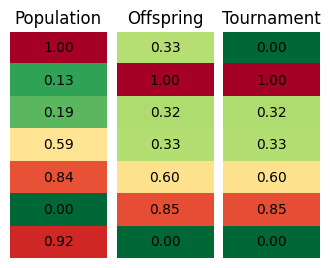

In [10]:
fig = plt.figure(figsize=(4, 4))
gs = gridspec.GridSpec(1,3)
gs.update(wspace=0.10, hspace=0.5) # set the spacing between axes. 
ax = []
ax.append(plt.subplot(gs[0]))
ax.append(plt.subplot(gs[1]))
ax.append(plt.subplot(gs[2]))
#plt.show()
cmap = matplotlib.cm.RdYlGn_r

n = 7
for i in range(n):
     ax[0].text(1, i, f'{pop1[i,0]:.2f}', ha='center', va='center', fontsize=10, color='black')
for i in range(n):
     ax[1].text(1, i, f'{pop2[i,0]:.2f}', ha='center', va='center', fontsize=10, color='black')

pop3=np.zeros((n,3))
pop3 = np.copy(pop1)
for i in range(n):
    if(pop2[i,0] < pop1[i,0]):
        pop3[i,:] = pop2[i,:]
    else:
        pop3[i,:] = pop1[i,:]


pop4 = np.copy(pop1)
pop4temp = np.vstack([pop1,pop2])
index = np.argsort(pop4temp[:,0])
pop4 = pop4temp[index[:n]]

pop5 = np.copy(pop2)
pop5[0] = pop1[np.argmin(pop1[:,0])]


pop6= np.copy(pop1)
pop6temp = np.vstack([pop1,pop2])
for i in range(n):
    sel1 = np.random.choice(2*n,1)
    sel2 = np.random.choice(2*n,1)
    if(pop6temp[sel1,0] < pop6temp[sel2,0]):
        pop6[i,:] = pop6temp[sel1,:]


pop3 = np.copy(pop5)

ax[0].imshow(pop1,cmap=cmap)
ax[0].set_title("Population")
ax[1].imshow(pop2,cmap=cmap)
ax[1].set_title("Offspring")

for i in range(n):
     ax[2].text(1, i, f'{pop3[i,0]:.2f}', ha='center', va='center', fontsize=10, color='black')
ax[2].imshow(pop3,cmap=cmap)
ax[2].set_title("Tournament")
#plt.colorbar()
#plt.show()
#plt.imshow(pop2)
#plt.show()
#plt.imshow(pop3)
ax[0].set_axis_off()  
ax[1].set_axis_off()  
ax[2].set_axis_off()  
plt.show()

#fig.savefig("tournament.png",bbox_inches="tight")

In [58]:
pop4temp

array([[0.98490458, 0.98490458, 0.98490458],
       [0.7949843 , 0.7949843 , 0.7949843 ],
       [0.44548702, 0.44548702, 0.44548702],
       [0.76856136, 0.76856136, 0.76856136],
       [0.        , 0.        , 0.        ],
       [0.11087927, 0.11087927, 0.11087927],
       [1.        , 1.        , 1.        ],
       [0.        , 0.        , 0.        ],
       [0.63102407, 0.63102407, 0.63102407],
       [0.01333305, 0.01333305, 0.01333305],
       [0.57489326, 0.57489326, 0.57489326],
       [0.8200644 , 0.8200644 , 0.8200644 ],
       [1.        , 1.        , 1.        ],
       [0.40155174, 0.40155174, 0.40155174]])

In [59]:
pop1

array([[0.98490458, 0.98490458, 0.98490458],
       [0.7949843 , 0.7949843 , 0.7949843 ],
       [0.44548702, 0.44548702, 0.44548702],
       [0.76856136, 0.76856136, 0.76856136],
       [0.        , 0.        , 0.        ],
       [0.11087927, 0.11087927, 0.11087927],
       [1.        , 1.        , 1.        ]])

In [68]:
pop1[np.argmin(pop1[:,0])]

array([0., 0., 0.])

array([9])

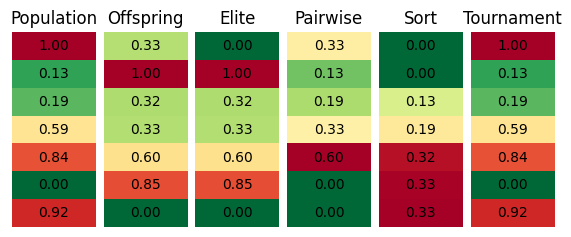

In [41]:
fig = plt.figure(figsize=(7, 4))
gs = gridspec.GridSpec(1,6)
gs.update(wspace=0.10, hspace=0.5) # set the spacing between axes. 
ax = []
ax.append(plt.subplot(gs[0]))
ax.append(plt.subplot(gs[1]))
ax.append(plt.subplot(gs[2]))
ax.append(plt.subplot(gs[3]))
ax.append(plt.subplot(gs[4]))
ax.append(plt.subplot(gs[5]))
#plt.show()
cmap = matplotlib.cm.RdYlGn_r

n = 7
for i in range(n):
     ax[0].text(1, i, f'{pop1[i,0]:.2f}', ha='center', va='center', fontsize=10, color='black')
for i in range(n):
     ax[1].text(1, i, f'{pop2[i,0]:.2f}', ha='center', va='center', fontsize=10, color='black')

pop3=np.zeros((n,3))
pop3 = np.copy(pop1)
for i in range(n):
    if(pop2[i,0] < pop1[i,0]):
        pop3[i,:] = pop2[i,:]
    else:
        pop3[i,:] = pop1[i,:]
pop3copy= np.copy(pop3)


pop4 = np.copy(pop1)
pop4temp = np.vstack([pop1,pop2])
index = np.argsort(pop4temp[:,0])
pop4 = pop4temp[index[:n]]

pop5 = np.copy(pop2)
pop5[0] = pop1[np.argmin(pop1[:,0])]


pop6= np.copy(pop1)
pop6temp = np.vstack([pop1,pop2])
for i in range(n):
    sel1 = np.random.choice(2*n,1)
    sel2 = np.random.choice(2*n,1)
    if(pop6temp[sel1,0] < pop6temp[sel2,0]):
        pop6[i,:] = pop6temp[sel1,:]



ax[0].imshow(pop1,cmap=cmap)
ax[0].set_title("Population")
ax[1].imshow(pop2,cmap=cmap)
ax[1].set_title("Offspring")

pop3 = np.copy(pop5)
for i in range(n):
     ax[2].text(1, i, f'{pop3[i,0]:.2f}', ha='center', va='center', fontsize=10, color='black')
ax[2].imshow(pop3,cmap=cmap)
ax[2].set_title("Elite")

pop3 = np.copy(pop3copy)
for i in range(n):
     ax[3].text(1, i, f'{pop3[i,0]:.2f}', ha='center', va='center', fontsize=10, color='black')
ax[3].imshow(pop3,cmap=cmap)
ax[3].set_title("Pairwise")

pop3 = np.copy(pop4)
for i in range(n):
     ax[4].text(1, i, f'{pop3[i,0]:.2f}', ha='center', va='center', fontsize=10, color='black')
ax[4].imshow(pop3,cmap=cmap)
ax[4].set_title("Sort")

pop3 = np.copy(pop6)
for i in range(n):
     ax[5].text(1, i, f'{pop3[i,0]:.2f}', ha='center', va='center', fontsize=10, color='black')
ax[5].imshow(pop3,cmap=cmap)
ax[5].set_title("Tournament")
#plt.colorbar()
#plt.show()
#plt.imshow(pop2)
#plt.show()
#plt.imshow(pop3)
ax[0].set_axis_off()  
ax[1].set_axis_off()  
ax[2].set_axis_off()  
ax[3].set_axis_off()  
ax[4].set_axis_off()  
ax[5].set_axis_off()  
plt.show()

fig.savefig("selections.png",bbox_inches="tight")

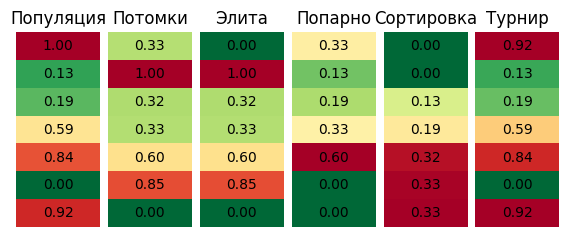

In [20]:
fig = plt.figure(figsize=(7, 4))
gs = gridspec.GridSpec(1,6)
gs.update(wspace=0.10, hspace=0.5) # set the spacing between axes. 
ax = []
ax.append(plt.subplot(gs[0]))
ax.append(plt.subplot(gs[1]))
ax.append(plt.subplot(gs[2]))
ax.append(plt.subplot(gs[3]))
ax.append(plt.subplot(gs[4]))
ax.append(plt.subplot(gs[5]))
#plt.show()
cmap = matplotlib.cm.RdYlGn_r

n = 7
for i in range(n):
     ax[0].text(1, i, f'{pop1[i,0]:.2f}', ha='center', va='center', fontsize=10, color='black')
for i in range(n):
     ax[1].text(1, i, f'{pop2[i,0]:.2f}', ha='center', va='center', fontsize=10, color='black')

pop3=np.zeros((n,3))
pop3 = np.copy(pop1)
for i in range(n):
    if(pop2[i,0] < pop1[i,0]):
        pop3[i,:] = pop2[i,:]
    else:
        pop3[i,:] = pop1[i,:]
pop3copy= np.copy(pop3)


pop4 = np.copy(pop1)
pop4temp = np.vstack([pop1,pop2])
index = np.argsort(pop4temp[:,0])
pop4 = pop4temp[index[:n]]

pop5 = np.copy(pop2)
pop5[0] = pop1[np.argmin(pop1[:,0])]


pop6= np.copy(pop1)
pop6temp = np.vstack([pop1,pop2])
for i in range(n):
    sel1 = np.random.choice(2*n,1)
    sel2 = np.random.choice(2*n,1)
    if(pop6temp[sel1,0] < pop6temp[sel2,0]):
        pop6[i,:] = pop6temp[sel1,:]



ax[0].imshow(pop1,cmap=cmap)
ax[0].set_title("Популяция")
ax[1].imshow(pop2,cmap=cmap)
ax[1].set_title("Потомки")

pop3 = np.copy(pop5)
for i in range(n):
     ax[2].text(1, i, f'{pop3[i,0]:.2f}', ha='center', va='center', fontsize=10, color='black')
ax[2].imshow(pop3,cmap=cmap)
ax[2].set_title("Элита")

pop3 = np.copy(pop3copy)
for i in range(n):
     ax[3].text(1, i, f'{pop3[i,0]:.2f}', ha='center', va='center', fontsize=10, color='black')
ax[3].imshow(pop3,cmap=cmap)
ax[3].set_title("Попарно")

pop3 = np.copy(pop4)
for i in range(n):
     ax[4].text(1, i, f'{pop3[i,0]:.2f}', ha='center', va='center', fontsize=10, color='black')
ax[4].imshow(pop3,cmap=cmap)
ax[4].set_title("Сортировка")

pop3 = np.copy(pop6)
for i in range(n):
     ax[5].text(1, i, f'{pop3[i,0]:.2f}', ha='center', va='center', fontsize=10, color='black')
ax[5].imshow(pop3,cmap=cmap)
ax[5].set_title("Турнир")
#plt.colorbar()
#plt.show()
#plt.imshow(pop2)
#plt.show()
#plt.imshow(pop3)
ax[0].set_axis_off()  
ax[1].set_axis_off()  
ax[2].set_axis_off()  
ax[3].set_axis_off()  
ax[4].set_axis_off()  
ax[5].set_axis_off()  
plt.show()

fig.savefig("selections_rus.png",bbox_inches="tight")